# 05 · Laboratoire de variables — froid, dynamique thermique, météo spatialisée, temps réel

**Question posée :** quelles nouvelles variables (ou quels réglages du modèle) améliorent *réellement* la prévision J+1, et en particulier par grand froid ?

**Ce notebook remplace la première version.** Les problèmes de celle-ci, corrigés ici :

| Problème de la v1 | Correction |
|---|---|
| `baseline` (météo observée) et `spatial` (météo prévue) comparés entre eux dans le tableau des folds | **Chaque variante est évaluée dans les deux modes météo**, toujours contre *sa* baseline dans le *même* mode |
| Modèles « prévision » entraînés sur ~9 ans de lignes sans météo (`mask_train` calculé mais jamais utilisé) | Protocole de **production** : entraînement sur la météo **observée**, service avec la météo **prévue débiaisée** (par heure, biais réestimé chaque mois) |
| Test de 2025 seul : aucune heure sous −5 °C, 381 demi-heures sous 0 °C | Évaluation **2018 → 2024** en rolling origin (hivers 2018, 2021… inclus) ; **2025 → aujourd'hui gardé intact** pour confirmer |
| Gains de 1-2 % interprétés sans mesure du bruit | **Test A/A** (bruit de graine) + **IC par bootstrap par blocs** + correction de multiplicité |
| Choix des variantes fait sur le jeu de test | Sélection sur 2018-2024, **confirmation aveugle** sur 2025+ avec le protocole de production |
| Pas de vérification que les variables respectent l'émission à 10 h | **Audit anti-fuite** automatique (consommation *et* météo observée) |

**Ce que l'on ajoute :**

- 9 familles de variables (froid/HDD, dynamique thermique, ressenti, astronomie, calendrier fin, temps réel de D, interactions, météo **spatialisée** par ville, températures brutes par ville) ;
- des tests de **modèle** (objectif L1/Huber, arbres linéaires, contraintes de monotonie, pondération, moyenne de graines) ;
- un **test d'extrapolation au froid** (entraîner sans les jours les plus froids, tester dessus) : c'est le vrai test de « grand froid », puisqu'un arbre ne peut pas extrapoler ;
- l'**ablation inversée** (retirer chaque famille de l'ensemble complet), la stabilité par année / saison / type de jour / heure, l'importance par permutation de blocs.

**Prérequis :** notebooks 01 (données, `meteo_openmeteo.parquet` par ville) et 03 (`meteo_forecast_openmeteo.parquet` par ville). Les résultats sont mis en cache dans `reports/feature_experiments/cache/` : relancer le notebook ne recalcule que ce qui a changé.

## 0. Configuration

Le profil règle le compromis vitesse / précision. Les temps sont indicatifs (dépendent de la machine) : le notebook affiche une estimation après le premier entraînement.

| Profil | Rolling origin | Arbres | Usage |
|---|---|---|---|
| `smoke` | 1 réentraînement / an | 30 | vérifier que tout s'exécute (résultats sans valeur) |
| `rapide` | 1 / an, dès 2021 | 150 | premier coup d'œil |
| `standard` | 1 / an, dès 2018 | 300 | **profil de travail** |
| `complet` | 1 / 6 mois, dès 2018 | 600 | décision finale (plusieurs heures) |

Le **jeu 2025 → fin des données consolidées n'est jamais utilisé pour choisir** : il ne sert qu'à la confirmation (section 13), avec le réentraînement mensuel et les hyperparamètres de production.

In [102]:
import os, sys, time, json, hashlib, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.options.display.max_columns = 60
pd.options.display.width = 220
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
try:
    import conso
except ImportError:
    sys.path.insert(0, str(ROOT / "src"))
    import conso

from conso.config import CITIES, CITY_WEIGHTS, DEFAULT_ROUNDS, FC_START, GAP_DAYS, ISSUE_HOUR, TZ, WCOLS
from conso.data import consolidated_end, load_dataset, load_national_forecast
from conso.features import FEATURE_COLUMNS, build_features
from conso.model import fit_lgb, predict_level
from conso.timeutils import local_days, mask_between, shift_local
from conso.weather import apply_hourly_bias, hourly_bias

RAW, PROC = ROOT / "data" / "raw", ROOT / "data" / "processed"
OUT = ROOT / "reports" / "feature_experiments"
CACHE, FIGS = OUT / "cache", ROOT / "reports" / "figures"
for p in (CACHE, FIGS):
    p.mkdir(parents=True, exist_ok=True)


def ts(s):
    return pd.Timestamp(s, tz=TZ)


def save_fig(name):
    plt.savefig(FIGS / f"{name}.png", dpi=130, bbox_inches="tight")


# ---------------------------------------------------------------- profil
PROFILE = os.environ.get("CONSO_NB_PROFILE", "standard")   # smoke | rapide | standard | complet
ALL_MODELS = ("obj_l1", "obj_huber", "linear_tree", "mono_hdd", "ff05", "leaves31", "hl3", "seed_avg3")
PROFILES = {
    "smoke":    dict(eval_start="2022-01-01", retrain=12, rounds=30,  n_boot=200,  null_seeds=(1,),      loo=True,  models=("obj_l1", "mono_hdd", "seed_avg3"), extrap=True,  confirm_rounds=40),
    "rapide":   dict(eval_start="2021-01-01", retrain=12, rounds=150, n_boot=500,  null_seeds=(1,),      loo=False, models=("obj_l1", "hl3"),                   extrap=False, confirm_rounds=300),
    "standard": dict(eval_start="2018-01-01", retrain=12, rounds=300, n_boot=2000, null_seeds=(1, 2),    loo=True,  models=ALL_MODELS,                          extrap=True,  confirm_rounds=None),
    "complet":  dict(eval_start="2018-01-01", retrain=6,  rounds=600, n_boot=3000, null_seeds=(1, 2, 3), loo=True,  models=ALL_MODELS,                          extrap=True,  confirm_rounds=None),
}
P = PROFILES[PROFILE]
ROUNDS = P["rounds"]

# ---------------------------------------------------------------- protocole
TRAIN_START = ts("2013-01-01")
HOLDOUT_START = ts("2025-01-01")          # jamais utilisé pour choisir une variante
EVAL_START = ts(P["eval_start"])          # début de la période de sélection (rolling origin)
FC_EVAL_START = ts("2023-01-01")          # mode prévu : la prévision historique commence en 2022, il faut >= 12 mois pour estimer le biais
BIAS_MONTHS = 24                          # comme la production
EVAL_EXCLUDE = [(ts("2020-03-01"), ts("2021-07-01"))]   # COVID : exclu des métriques (pas de l'entraînement)
HIST_DAYS, LOOKAHEAD_DAYS = 90, 15       # fenêtre de calcul des variables (historique / jours futurs connus : calendrier)
FORCE_REFRESH = False                     # True = ignore le cache
print(f"Profil : {PROFILE} | {P}")

Profil : standard | {'eval_start': '2018-01-01', 'retrain': 12, 'rounds': 300, 'n_boot': 2000, 'null_seeds': (1, 2), 'loo': True, 'models': ('obj_l1', 'obj_huber', 'linear_tree', 'mono_hdd', 'ff05', 'leaves31', 'hl3', 'seed_avg3'), 'extrap': True, 'confirm_rounds': None}


## 1. Données

- consommation et météo nationale : `dataset_30min.parquet` (notebook 01) ;
- **température par ville, observée** (`meteo_openmeteo.parquet`, notebook 01) et **prévue** (`meteo_forecast_openmeteo.parquet`, notebook 03), interpolées au pas de 30 min comme l'agrégat national.

Contrôle : la moyenne pondérée des villes doit retrouver la température nationale du jeu de données.

In [103]:
df = load_dataset(PROC / "dataset_30min.parquet")
y = df["conso"]
wt_obs = df[WCOLS]
TEST_END = consolidated_end(df).tz_convert(TZ)
print(f"{len(df):,} lignes | {df.index.min()} → {df.index.max()} | consolidé jusqu'au {TEST_END}")

CITY_NAMES = list(CITIES)
W = pd.Series(CITY_WEIGHTS)[CITY_NAMES]
W = W / W.sum()


def load_city_temp(path):
    m = pd.read_parquet(path)
    if m.index.tz is None:
        m.index = m.index.tz_localize("UTC")
    piv = m.rename_axis("time").reset_index().pivot_table(index="time", columns="city", values="temperature_2m", aggfunc="mean").sort_index()
    piv = piv.reindex(columns=CITY_NAMES)
    if piv.isna().all().any():
        raise ValueError(f"Villes sans données dans {path.name} : {piv.columns[piv.isna().all()].tolist()}")
    return piv.resample("30min").interpolate(method="time").reindex(df.index)


HAS_CITY_OBS = (RAW / "meteo_openmeteo.parquet").exists()
HAS_FC = (RAW / "meteo_forecast_openmeteo.parquet").exists()
CT_OBS = load_city_temp(RAW / "meteo_openmeteo.parquet") if HAS_CITY_OBS else None
CT_FC = load_city_temp(RAW / "meteo_forecast_openmeteo.parquet") if HAS_FC else None
WT_FC = load_national_forecast(RAW / "meteo_forecast_openmeteo.parquet", df.index) if HAS_FC else None
MODES = ["oracle", "fc_debiased"] if HAS_FC else ["oracle"]
print("Météo par ville observée :", HAS_CITY_OBS, "| prévue :", HAS_FC, "| modes évalués :", MODES)

if HAS_CITY_OBS:
    nat_check = CT_OBS.mul(W, axis=1).sum(axis=1, min_count=len(W))
    gap = (nat_check - df["temp_nat"]).abs()
    print(f"Moyenne pondérée des villes vs temp_nat : écart max {gap.max():.3f} °C, moyen {gap.mean():.4f} °C")
    if gap.max() > 0.1:
        print("⚠ écart notable : vérifier que meteo_openmeteo.parquet est bien celui qui a servi au notebook 01.")

240,458 lignes | 2013-01-01 00:00:00+00:00 → 2026-09-19 12:30:00+00:00 | consolidé jusqu'au 2026-07-01 00:00:00+02:00
Météo par ville observée : True | prévue : True | modes évalués : ['oracle', 'fc_debiased']
Moyenne pondérée des villes vs temp_nat : écart max 0.000 °C, moyen 0.0000 °C


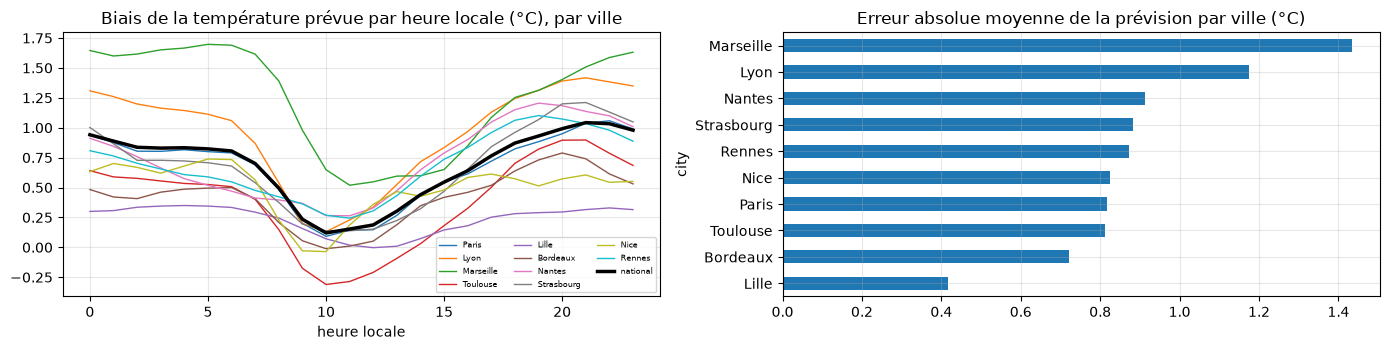

Le biais horaire diffère selon les villes : en mode prévu, chaque ville est débiaisée avec son propre biais.


In [104]:
if HAS_FC and HAS_CITY_OBS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
    diff = (CT_FC - CT_OBS).loc[FC_START:].dropna()
    diff.groupby(diff.index.tz_convert(TZ).hour).mean().plot(ax=axes[0], lw=1)
    nat = (WT_FC["temp_nat"] - wt_obs["temp_nat"]).loc[FC_START:].dropna()
    nat.groupby(nat.index.tz_convert(TZ).hour).mean().plot(ax=axes[0], color="k", lw=2.5, label="national")
    axes[0].set_title("Biais de la température prévue par heure locale (°C), par ville"); axes[0].set_xlabel("heure locale")
    axes[0].legend(fontsize=6, ncol=3)
    diff.abs().mean().sort_values().plot.barh(ax=axes[1])
    axes[1].set_title("Erreur absolue moyenne de la prévision par ville (°C)")
    plt.tight_layout(); save_fig("05_biais_meteo_par_ville"); plt.show()
    print("Le biais horaire diffère selon les villes : en mode prévu, chaque ville est débiaisée avec son propre biais.")

## 2. Règle d'information : ce qui est connu à l'émission

Prévision émise le jour **D à 10 h** pour le jour cible **T = D+1**. Toute variable doit respecter :

| Information | Source autorisée |
|---|---|
| consommation | jusqu'à D 9 h 30 (le test anti-fuite de la section 4 le vérifie) |
| météo du jour T et du jour D | météo « mode cible » `wt` : **prévue** en exploitation, observée en mode oracle |
| météo des jours ≤ T−2 | **observée** |

Les variables du dépôt (`te`, `t_roll3`) utilisent la température *observée* du jour D en entier, y compris l'après-midi qui n'est pas encore connu à 10 h : c'est un petit optimisme, **commun à toutes les variantes**, et l'audit de la section 4 le rend visible. Pour les **nouvelles** variables, on applique la règle stricte ci-dessus : `Ctx.past(k, …)` prend le mode cible pour T et D, l'observé au-delà.

## 3. Familles de variables

Chaque famille est un **bloc** : une fonction `(Ctx, X_base) → DataFrame`. On teste chaque bloc *ajouté* à la baseline, puis l'ensemble, puis chaque bloc *retiré* de l'ensemble.

| Bloc | Hypothèse testée |
|---|---|
| `dyn` | l'inertie thermique du bâti (moyennes exponentielles multi-échelles), la variation de température sur 24/48 h et les séries de jours froids expliquent des écarts que `te` (une seule échelle) ne capte pas |
| `hdd` | le chauffage suit des degrés-jours à plusieurs seuils (12/15/17 °C) et sur plusieurs horizons (jour, 3 j, 14 j) |
| `ressenti` | le vent (refroidissement éolien) augmente le chauffage ; humidex et degrés-jours de climatisation expliquent les pointes d'été |
| `astro` | l'éclairage suit le soleil (élévation, durée du jour, heures depuis le lever / avant le coucher), pas l'heure d'horloge |
| `cal` | jours avant / après un férié, période de Noël, jours de changement d'heure, densité de fériés dans la semaine |
| `nowcast` | la matinée de D (avant 10 h) informe sur le comportement du jour : dernier point connu, pente, écart des 3 dernières heures, écart de température du matin |
| `inter` | le profil intrajournalier dépend de la température : interactions HDD × heure (sinus / cosinus), × week-end, × férié |
| `spatial_hdd` | la moyenne nationale masque l'étendue du froid : **HDD pondéré par ville** (la moyenne des HDD n'est pas le HDD de la moyenne), part de la population sous 0 / 5 °C, dispersion, gradients nord-sud et est-ouest |
| `spatial_villes` | (témoin) les 10 températures brutes des villes, très corrélées entre elles |

In [105]:
class Ctx:
    """Tout ce dont un bloc a besoin, aligné sur ``d.index`` (UTC, pas de 30 min).

    d      : consommation, météo nationale OBSERVÉE, calendrier
    wt     : météo nationale au moment cible (observée en mode oracle, prévue en mode prévu)
    ct     : température par ville au moment cible (mêmes conventions que ``wt``)
    ct_obs : température OBSERVÉE par ville
    """

    def __init__(self, d, wt, ct, ct_obs):
        self.d, self.wt, self.ct, self.ct_obs = d, wt, ct, ct_obs
        loc = d.index.tz_convert(TZ)
        self.day = local_days(d.index)
        self.hh = np.asarray(loc.hour + loc.minute / 60)
        self.dow = np.asarray(loc.dayofweek)
        self.early = self.hh < ISSUE_HOUR
        self.dm = self.daily(wt["temp_nat"])       # température moyenne journalière, mode cible
        self.do = self.daily(d["temp_nat"])        # idem, observée

    def daily(self, s, how="mean"):
        return getattr(s.groupby(self.day), how)().asfreq("D")

    def rows(self, s):
        # série indexée par jour -> valeur pour chaque demi-heure du jour
        return pd.Series(s.reindex(self.day).to_numpy(), index=self.d.index)

    @staticmethod
    def past(k, mode_s, obs_s):
        # valeur du jour T-k, sans information postérieure à l'émission (D = T-1, 10 h)
        if k == 0:
            return mode_s
        return mode_s.shift(1) if k == 1 else obs_s.shift(k)


def blk_dyn(c, X):
    o = pd.DataFrame(index=c.d.index)
    t = c.wt["temp_nat"]
    o["dtemp_24h"] = t - shift_local(t, 1)                       # vs même créneau de D (mode cible)
    o["dtemp_48h"] = t - shift_local(c.d["temp_nat"], 2)         # vs même créneau de T-2 (observé)
    p1, p2, p3 = (Ctx.past(k, c.dm, c.do) for k in (1, 2, 3))
    o["dTj_1j"] = c.rows(c.dm - p1)
    o["dTj_3j"] = c.rows(c.dm - (p1 + p2 + p3) / 3)
    for a, tag in ((0.15, "lent"), (0.35, "moyen"), (0.7, "rapide")):
        ew = c.do.ewm(alpha=a, adjust=False).mean().where(c.do.notna())
        e_D = a * c.dm.shift(1) + (1 - a) * ew.shift(2)          # état de la moyenne exponentielle à D
        o[f"te_{tag}"] = c.rows(a * c.dm + (1 - a) * e_D)
    o["dT_te_lent"] = t - o["te_lent"]
    mn_m, mn_o = c.daily(t, "min"), c.daily(c.d["temp_nat"], "min")
    o["tmin_3j"] = c.rows(pd.concat([mn_m, mn_m.shift(1), mn_o.shift(2)], axis=1).min(axis=1, skipna=False))
    for thr in (0, 5):                                            # jours froids consécutifs finissant en T
        cold_o = (c.do < thr).astype(int)
        streak_o = cold_o.groupby((1 - cold_o).cumsum()).cumsum().where(c.do.notna())
        sT = (c.dm < thr).astype(float).where(c.dm.notna())
        sD = (c.dm.shift(1) < thr).astype(float).where(c.dm.shift(1).notna())
        o[f"serie_froid_{thr}"] = c.rows(sT * (1 + sD * (1 + streak_o.shift(2).fillna(0))))
    return o


def blk_hdd(c, X):
    o = pd.DataFrame(index=c.d.index)
    for b in (12, 15, 17):
        hm, ho = (b - c.dm).clip(lower=0), (b - c.do).clip(lower=0)
        o[f"hdd{b}_j"] = c.rows(hm)
        o[f"hdd{b}_3j"] = c.rows((hm.shift(1) + ho.shift(2) + ho.shift(3)) / 3)
        o[f"hdd{b}_14j"] = c.rows((hm.shift(1) + ho.shift(2).rolling(13, min_periods=13).sum()) / 14)
    return o


def blk_ressenti(c, X):
    o = pd.DataFrame(index=c.d.index)
    t, v, h = c.wt["temp_nat"], c.wt["wind_nat"], c.wt["hum_nat"]
    v16 = v.clip(lower=4.8) ** 0.16                               # vent en km/h (Open-Meteo)
    wc = 13.12 + 0.6215 * t - 11.37 * v16 + 0.3965 * t * v16      # refroidissement éolien
    o["t_ressentie_froid"] = wc.where(t <= 10, t)
    o["ecart_vent"] = t - o["t_ressentie_froid"]
    g = np.log(h.clip(lower=1, upper=100) / 100) + 17.625 * t / (243.04 + t)
    td = 243.04 * g / (17.625 - g)                                # point de rosée (Magnus)
    e = 6.11 * np.exp(5417.753 * (1 / 273.16 - 1 / (273.15 + td)))
    o["humidex"] = (t + 0.5555 * (e - 10)).where(t >= 20, t)
    mx_m, mx_o = c.daily(t, "max"), c.daily(c.d["temp_nat"], "max")
    mn_m, mn_o = c.daily(t, "min"), c.daily(c.d["temp_nat"], "min")
    o["tmax_3j"] = c.rows((mx_m + mx_m.shift(1) + mx_o.shift(2)) / 3)
    o["tmin_nuit_3j"] = c.rows((mn_m + mn_m.shift(1) + mn_o.shift(2)) / 3)
    cm, co = (c.dm - 22).clip(lower=0), (c.do - 22).clip(lower=0)
    o["cdd22_j"] = c.rows(cm)
    o["cdd22_3j"] = c.rows((cm.shift(1) + co.shift(2) + co.shift(3)) / 3)
    return o


def blk_astro(c, X):
    idx = c.d.index.tz_convert("UTC")
    doy, hut = np.asarray(idx.dayofyear), np.asarray(idx.hour + idx.minute / 60)
    g = 2 * np.pi / 365 * (doy - 1 + (hut - 12) / 24)
    decl = (0.006918 - 0.399912 * np.cos(g) + 0.070257 * np.sin(g) - 0.006758 * np.cos(2 * g)
            + 0.000907 * np.sin(2 * g) - 0.002697 * np.cos(3 * g) + 0.00148 * np.sin(3 * g))
    eqt = 229.18 * (0.000075 + 0.001868 * np.cos(g) - 0.032077 * np.sin(g) - 0.014615 * np.cos(2 * g) - 0.040849 * np.sin(2 * g))
    lat, lon = np.radians(46.6), 2.5                              # centre de la France
    tst = (hut * 60 + eqt + 4 * lon) % 1440                       # temps solaire vrai (minutes)
    ha = np.radians(tst / 4 - 180)
    sin_el = np.sin(lat) * np.sin(decl) + np.cos(lat) * np.cos(decl) * np.cos(ha)
    dur = 2 * np.degrees(np.arccos(np.clip(-np.tan(lat) * np.tan(decl), -1, 1))) / 15
    hs = tst / 60
    o = pd.DataFrame(index=c.d.index)
    o["sun_elev"] = np.degrees(np.arcsin(np.clip(sin_el, -1, 1)))
    o["duree_jour"] = dur
    o["h_depuis_lever"] = hs - (12 - dur / 2)
    o["h_avant_coucher"] = (12 + dur / 2) - hs
    return o


def blk_cal(c, X):
    o = pd.DataFrame(index=c.d.index)
    hol = c.d["is_holiday"].astype(float).groupby(c.day).max().asfreq("D")
    pos = np.arange(len(hol), dtype=float)
    mark = pd.Series(np.where(hol.to_numpy() == 1, pos, np.nan), index=hol.index)
    nxt, prv = mark.shift(-1).bfill(), mark.shift(1).ffill()      # prochain / précédent jour férié (strictement)
    o["j_avant_ferie"] = c.rows((nxt - pos).clip(upper=10).fillna(10))
    o["j_depuis_ferie"] = c.rows((pos - prv).clip(upper=10).fillna(10))
    m, dom = c.day.month, c.day.day
    o["noel_nouvel_an"] = ((m == 12) & (dom >= 24)) | ((m == 1) & (dom <= 2))
    o["noel_nouvel_an"] = o["noel_nouvel_an"].astype(float)
    n_slots = pd.Series(1, index=c.d.index).groupby(c.day).sum().asfreq("D")
    o["dst_jour"] = c.rows(n_slots - 48)                          # -2 (printemps) / +2 (automne) / 0
    o["n_feries_7j"] = c.rows(hol.rolling(7, center=True, min_periods=7).sum())
    return o


def blk_nowcast(c, X):
    o = pd.DataFrame(index=c.d.index)
    yy, hh = c.d["conso"], c.hh

    def slot(h):
        k = np.isclose(hh, h)
        return yy[k].groupby(c.day[k]).first().asfreq("D")

    y930, y730 = slot(9.5), slot(7.5)
    o["y_last_rel"] = c.rows(y930.shift(1)) - X["level7"]         # dernier point connu de D, relatif au niveau
    slope = y930 - y730
    o["pente_matin_dev"] = c.rows((slope - slope.shift(7)).shift(1))
    rec = (hh >= 7) & (hh < 10)
    m_rec = yy[rec].groupby(c.day[rec]).mean().asfreq("D")
    o["dev_recent_3h"] = c.rows((m_rec - m_rec.shift(7)).shift(1))
    m_early = yy[c.early].groupby(c.day[c.early]).mean().asfreq("D")
    o["dev_matin_j1"] = c.rows((m_early - m_early.shift(1)).shift(1))
    t_early = c.d["temp_nat"][c.early].groupby(c.day[c.early]).mean().asfreq("D")
    o["dtemp_matin"] = c.rows((t_early - t_early.shift(7)).shift(1))   # de combien D est plus chaud/froid que D-7 le matin
    return o


def blk_inter(c, X):
    t = c.wt["temp_nat"]
    hdd, ang = (17 - t).clip(lower=0), 2 * np.pi * c.hh / 24
    o = pd.DataFrame(index=c.d.index)
    o["hdd17_sin_h"], o["hdd17_cos_h"] = hdd * np.sin(ang), hdd * np.cos(ang)
    o["hdd17_x_weekend"] = hdd * (c.dow >= 5)
    o["hdd17_x_ferie"] = hdd * X["is_holiday"]
    return o


def blk_spat(c, X):
    T, To, n = c.ct, c.ct_obs, c.ct.shape[1]
    w = W.reindex(T.columns)
    o = pd.DataFrame(index=c.d.index)
    mu = T.mul(w, axis=1).sum(axis=1, min_count=n)
    o["hdd17_pop"] = (17 - T).clip(lower=0).mul(w, axis=1).sum(axis=1, min_count=n)
    o["ecart_hdd_pop"] = o["hdd17_pop"] - (17 - c.wt["temp_nat"]).clip(lower=0)   # non-linéarité de l'agrégation
    dev = T.sub(mu, axis=0)
    o["t_disp"] = np.sqrt((dev ** 2).mul(w, axis=1).sum(axis=1, min_count=n))
    o["t_min_ville"], o["t_max_ville"] = T.min(axis=1, skipna=False), T.max(axis=1, skipna=False)
    for nm, i in (("grad_nord_sud", 0), ("grad_est_ouest", 1)):
        xs = pd.Series({k: CITIES[k][i] for k in T.columns})
        xc = xs - (xs * w).sum()
        o[nm] = dev.mul(w * xc, axis=1).sum(axis=1, min_count=n) / (w * xc ** 2).sum()
    Tj = T.groupby(c.day).mean().asfreq("D")
    ok = Tj.notna().all(axis=1)
    o["pop_j_lt0"] = c.rows((Tj < 0).mul(w, axis=1).sum(axis=1).where(ok))
    o["pop_j_lt5"] = c.rows((Tj < 5).mul(w, axis=1).sum(axis=1).where(ok))
    Toj = To.groupby(c.day).mean().asfreq("D")
    hm = (17 - Tj).clip(lower=0).mul(w, axis=1).sum(axis=1, min_count=n)
    ho = (17 - Toj).clip(lower=0).mul(w, axis=1).sum(axis=1, min_count=n)
    o["hdd17_pop_j"] = c.rows(hm)
    o["hdd17_pop_3j"] = c.rows((hm.shift(1) + ho.shift(2) + ho.shift(3)) / 3)
    o["hdd17_pop_7j"] = c.rows((hm.shift(1) + ho.shift(2).rolling(6, min_periods=6).sum()) / 7)
    return o


def blk_villes(c, X):
    o = pd.DataFrame(index=c.d.index)
    for city in c.ct.columns:
        o[f"t_{city.lower()}"] = c.ct[city]
    return o


BLOCKS = {"dyn": blk_dyn, "hdd": blk_hdd, "ressenti": blk_ressenti, "astro": blk_astro, "cal": blk_cal,
          "nowcast": blk_nowcast, "inter": blk_inter, "spatial_hdd": blk_spat, "spatial_villes": blk_villes}
if not HAS_CITY_OBS:
    BLOCKS = {k: v for k, v in BLOCKS.items() if not k.startswith("spatial")}
    print("Pas de météo par ville : blocs spatiaux ignorés.")


def build_all(d, wt, ct, ct_obs):
    # variables de production + tous les blocs, sur les lignes de d
    c = Ctx(d, wt, ct, ct_obs)
    Xb = build_features(d, wt)
    parts = {b: fn(c, Xb).astype("float32") for b, fn in BLOCKS.items()}
    return Xb, parts


def build_window(ms, me, wt_full, ct_full):
    # variables des lignes de [ms, me[, calculées sur une fenêtre (historique + jours futurs du calendrier)
    lo, hi = ms - pd.Timedelta(days=HIST_DAYS), me + pd.Timedelta(days=LOOKAHEAD_DAYS)
    sel = mask_between(df.index, lo, hi)
    Xb, parts = build_all(df.loc[sel], wt_full.loc[sel],
                          None if ct_full is None else ct_full.loc[sel], None if CT_OBS is None else CT_OBS.loc[sel])
    X = pd.concat([Xb, *parts.values()], axis=1)
    return X.loc[mask_between(X.index, ms, me)]

## 4. Audits automatiques

Trois vérifications **avant** tout entraînement. Si l'une échoue, le notebook s'arrête.

1. **Consommation** : on efface la consommation à partir de D 10 h, on reconstruit toutes les variables (production + nouveaux blocs) et on vérifie que celles du jour T ne bougent pas (équivalent élargi de `tests/test_features.py::test_no_leakage`).
2. **Météo observée** : on efface la météo observée à partir de D 10 h (en conservant la météo « mode cible », qui représente la prévision) : aucune **nouvelle** variable ne doit changer. Les variables de production qui changent sont listées (optimisme connu et commun).
3. **Fenêtre = historique complet** : calculer les variables sur une fenêtre de 90 jours donne les mêmes valeurs que sur tout l'historique (c'est ce qui est fait en mode prévu, mois par mois).

Chaque audit contient un contrôle de sensibilité : effacer aussi des données *antérieures* doit bien faire bouger les variables, sinon l'audit ne détecte rien.

In [106]:
def _changed(A, B, sel, rtol=1e-6, atol=1e-6):
    return [c for c in A.columns
            if not np.allclose(A.loc[sel, c].to_numpy(dtype=float), B.loc[sel, c].to_numpy(dtype=float), equal_nan=True, rtol=rtol, atol=atol)]


def _concat(Xb, parts):
    return pd.concat([Xb, *parts.values()], axis=1)


def audit_features():
    T0 = (TEST_END - pd.Timedelta(days=400)).tz_localize(None).normalize()      # un jour de la période, hors changement d'heure
    for _ in range(6):
        sub = df.loc[ts(str((T0 - pd.Timedelta(days=100)).date())): ts(str((T0 + pd.Timedelta(days=16)).date()))]
        sel = local_days(sub.index) == T0
        if sel.sum() == 48:
            break
        T0 += pd.Timedelta(days=1)
    assert sel.sum() == 48, f"jour cible {T0.date()} introuvable ou incomplet"
    cutoff = ts(str((T0 - pd.Timedelta(days=1)).date()) + " 10:00")               # émission : D 10 h
    wt_s = sub[WCOLS]
    ct_s = None if CT_OBS is None else CT_OBS.loc[sub.index]
    Xb0, parts0 = build_all(sub, wt_s, ct_s, ct_s)
    XA = _concat(Xb0, parts0)
    new_cols = {c for p in parts0.values() for c in p.columns}

    # 1) consommation
    s1 = sub.copy()
    s1.loc[s1.index >= cutoff, "conso"] = np.nan
    ch1 = _changed(XA, _concat(*build_all(s1, wt_s, ct_s, ct_s)), sel)
    assert not ch1, f"FUITE (consommation) : {ch1}"
    s1b = sub.copy()
    s1b.loc[s1b.index >= T0.tz_localize(TZ) - pd.Timedelta(days=9), "conso"] = np.nan
    assert _changed(XA, _concat(*build_all(s1b, wt_s, ct_s, ct_s)), sel), "l'audit consommation est insensible"
    print(f"✔ 1/3 consommation : aucune variable du {T0.date()} ne dépend de la consommation postérieure à D 10 h")

    # 2) météo observée (la météo « mode cible » wt reste intacte : elle représente la prévision)
    def erase_obs(t_from):
        s2 = sub.copy()
        s2.loc[s2.index >= t_from, WCOLS] = np.nan
        c2 = None
        if ct_s is not None:
            c2 = ct_s.copy()
            c2.loc[c2.index >= t_from] = np.nan
        return _concat(*build_all(s2, wt_s, ct_s, c2))

    ch2 = _changed(XA, erase_obs(cutoff), sel)
    bad = [c for c in ch2 if c in new_cols]
    known = [c for c in ch2 if c not in new_cols]
    assert not bad, f"FUITE (météo observée après D 10 h) dans les nouvelles variables : {bad}"
    assert set(_changed(XA, erase_obs(T0.tz_localize(TZ) - pd.Timedelta(days=9)), sel)) & new_cols, "l'audit météo est insensible"
    print("✔ 2/3 météo observée : aucune nouvelle variable n'utilise l'observé postérieur à D 10 h")
    print(f"   (variables de production qui l'utilisent, optimisme commun à toutes les variantes : {known})")
    return known


KNOWN_OPTIMISM = audit_features()

✔ 1/3 consommation : aucune variable du 2025-05-27 ne dépend de la consommation postérieure à D 10 h
✔ 2/3 météo observée : aucune nouvelle variable n'utilise l'observé postérieur à D 10 h
   (variables de production qui l'utilisent, optimisme commun à toutes les variantes : ['te', 't_roll3', 'dT'])


In [107]:
class Store:
    """Matrices de variables : mode oracle sur tout l'historique, mode prévu mois par mois (biais réestimé chaque mois)."""

    def __init__(self):
        t0 = time.time()
        Xb, parts = build_all(df, wt_obs, CT_OBS, CT_OBS)
        self.obs = _concat(Xb, parts)
        self.block_cols = {b: list(p.columns) for b, p in parts.items()}
        allc = [c for cols in self.block_cols.values() for c in cols]
        assert len(allc) == len(set(allc)) and not set(allc) & set(self.obs.columns[: len(Xb.columns)]), "noms de colonnes en double"
        self.col_block = {c: b for b, cols in self.block_cols.items() for c in cols} | {c: "base" for c in FEATURE_COLUMNS}
        self.fc_cache = {}
        print(f"Variables : {len(FEATURE_COLUMNS)} de base + {len(allc)} nouvelles en {len(self.block_cols)} blocs "
              f"({self.obs.shape[0]:,} lignes, {time.time() - t0:.0f} s)")

    def fc_month(self, ms):
        if ms in self.fc_cache:
            return self.fc_cache[ms]
        me = ms + pd.DateOffset(months=1)
        train_end = ms - pd.Timedelta(days=GAP_DAYS)
        b0 = train_end - pd.DateOffset(months=BIAS_MONTHS)
        wt_deb = apply_hourly_bias(WT_FC, hourly_bias(WT_FC, wt_obs, b0, train_end))     # biais national : comme la production
        ct_deb = None
        if CT_FC is not None and CT_OBS is not None:
            ok = mask_between(CT_FC.index, b0, train_end)
            dif = (CT_FC - CT_OBS).loc[ok]
            bias_c = dif.groupby(dif.index.tz_convert(TZ).hour).mean().reindex(range(24)).fillna(0.0)
            ct_deb = CT_FC - bias_c.reindex(CT_FC.index.tz_convert(TZ).hour).to_numpy()   # biais propre à chaque ville et à chaque heure
        X = build_window(ms, me, wt_deb, ct_deb)
        self.fc_cache[ms] = X
        return X


STORE = Store()
BLOCK_COLS = STORE.block_cols
for b, cols in BLOCK_COLS.items():
    print(f"  {b:15s} {len(cols):2d} : {', '.join(cols)}")

Variables : 39 de base + 67 nouvelles en 9 blocs (240,458 lignes, 19 s)
  dyn             11 : dtemp_24h, dtemp_48h, dTj_1j, dTj_3j, te_lent, te_moyen, te_rapide, dT_te_lent, tmin_3j, serie_froid_0, serie_froid_5
  hdd              9 : hdd12_j, hdd12_3j, hdd12_14j, hdd15_j, hdd15_3j, hdd15_14j, hdd17_j, hdd17_3j, hdd17_14j
  ressenti         7 : t_ressentie_froid, ecart_vent, humidex, tmax_3j, tmin_nuit_3j, cdd22_j, cdd22_3j
  astro            4 : sun_elev, duree_jour, h_depuis_lever, h_avant_coucher
  cal              5 : j_avant_ferie, j_depuis_ferie, noel_nouvel_an, dst_jour, n_feries_7j
  nowcast          5 : y_last_rel, pente_matin_dev, dev_recent_3h, dev_matin_j1, dtemp_matin
  inter            4 : hdd17_sin_h, hdd17_cos_h, hdd17_x_weekend, hdd17_x_ferie
  spatial_hdd     12 : hdd17_pop, ecart_hdd_pop, t_disp, t_min_ville, t_max_ville, grad_nord_sud, grad_est_ouest, pop_j_lt0, pop_j_lt5, hdd17_pop_j, hdd17_pop_3j, hdd17_pop_7j
  spatial_villes  10 : t_paris, t_lyon, t_marseille, 

In [108]:
# 3/3 : la fenêtre donne les mêmes valeurs que l'historique complet (mode oracle, dont un jour de changement d'heure)
def audit_window():
    dates = [ts("2023-03-15"), ts("2023-10-29"), ts("2024-03-31"), ts("2024-12-10")]
    for ms in dates:
        me = ms + pd.Timedelta(days=1)
        if ms < df.index[0] + pd.Timedelta(days=HIST_DAYS + 5) or me > df.index[-1] - pd.Timedelta(days=LOOKAHEAD_DAYS + 1):
            continue
        Xw = build_window(ms, me, wt_obs, CT_OBS)
        ref = STORE.obs.loc[Xw.index]
        bad = _changed(Xw, ref, np.ones(len(Xw), bool), rtol=1e-4, atol=2e-3)
        assert not bad, f"fenêtre != historique complet le {ms.date()} : {bad}"
    print("✔ 3/3 les variables calculées sur une fenêtre de 90 jours = celles de l'historique complet")


audit_window()

✔ 3/3 les variables calculées sur une fenêtre de 90 jours = celles de l'historique complet


## 5. Moteur d'expériences

`run_variant` exécute le protocole de **rolling origin** pour un jeu de variables et des réglages donnés :

- tous les `retrain` mois, entraînement sur la météo **observée** de `2013-01-01` à `début − 2 jours` (`conso.model.fit_lgb`, le code de production) ;
- pour chaque mois : prévision en **mode oracle** (météo observée) et en **mode prévu débiaisé** (biais horaire réestimé chaque mois sur les 24 mois précédents, national *et* par ville) ;
- résultats mis en **cache** (clé = variables, réglages, checksum des valeurs) : ajouter une variante ne recalcule pas les autres.

Toutes les variantes partagent **exactement** le même protocole, les mêmes horodatages et le même nombre d'arbres : seules les variables (ou le réglage testé) changent.

In [109]:
PRED = {}                 # nom -> DataFrame(colonnes : oracle, fc_debiased)
_RUNS = []


def _checksum(cols):
    if not cols:
        return 0.0
    return round(float(np.nansum(STORE.obs[cols].iloc[::997].to_numpy(dtype="float64"))), 3)


def run_variant(name, cols=(), *, params=None, rounds=None, seeds=(0,), half_life=None, mono_cols=(),
                exclude_train=None, start=None, end=None, retrain=None, modes=None, force=False, verbose=True):
    cols = list(cols)
    feats = FEATURE_COLUMNS + cols
    rounds, params = rounds or ROUNDS, dict(params or {})
    start, end = start or EVAL_START, end or HOLDOUT_START
    retrain, modes = retrain or P["retrain"], list(modes or MODES)
    key = json.dumps(dict(cols=sorted(cols), params=params, rounds=rounds, seeds=list(seeds), hl=half_life, mono=sorted(mono_cols),
                          excl=None if exclude_train is None else hashlib.md5(np.packbits(exclude_train).tobytes()).hexdigest(),
                          a=str(start), b=str(end), rt=retrain, modes=modes, chk=_checksum(cols), v=conso.__version__,
                          tr=str(TRAIN_START)), sort_keys=True, default=str)
    path = CACHE / f"{name}_{hashlib.md5(key.encode()).hexdigest()[:10]}.parquet"
    if path.exists() and not force and not FORCE_REFRESH:
        PRED[name] = pd.read_parquet(path)
        if verbose:
            print(f"  {name:28s} cache")
        return PRED[name]

    mono = [1 if f in set(mono_cols) else 0 for f in feats] if mono_cols else None
    months = list(pd.date_range(start, end - pd.Timedelta("1min"), freq="MS"))
    X = STORE.obs
    parts, n_fit, t0 = [], 0, time.time()
    for k in range(0, len(months), retrain):
        blk = months[k:k + retrain]
        train_end = blk[0] - pd.Timedelta(days=GAP_DAYS)
        tm = mask_between(X.index, TRAIN_START, train_end)
        if exclude_train is not None:
            tm = tm & ~exclude_train
        prm = {**params, **({"monotone_constraints": mono} if mono else {})}
        models = [fit_lgb(X, y, tm, rounds, {**prm, "seed": s}, half_life, train_end, feats) for s in seeds]
        n_fit += len(models)
        for ms in blk:
            me = ms + pd.DateOffset(months=1)
            out = {}
            Xo = X.loc[mask_between(X.index, ms, me)]
            out["oracle"] = pd.concat([predict_level(m, Xo, feats) for m in models], axis=1).mean(axis=1)
            if "fc_debiased" in modes and ms >= FC_EVAL_START:
                Xf = STORE.fc_month(ms)
                out["fc_debiased"] = pd.concat([predict_level(m, Xf, feats) for m in models], axis=1).mean(axis=1)
            parts.append(pd.DataFrame(out))
    res = pd.concat(parts)
    res.to_parquet(path)
    PRED[name] = res
    dt = time.time() - t0
    _RUNS.append((name, n_fit, dt))
    if verbose:
        print(f"  {name:28s} {n_fit:3d} entraînements, {dt:5.0f} s ({dt / max(n_fit, 1):.1f} s / entraînement, {len(feats)} variables)")
    return res

## 6. Outils de mesure

- **MAE / RMSE / biais / MAPE / erreur sur la pointe journalière**, sur des points strictement communs à toutes les variantes comparées (COVID exclu).
- **Gain** = `(MAE_réf − MAE_variante) / MAE_réf`. Son incertitude est mesurée par un **bootstrap par blocs** de 7 jours sur les erreurs *appariées* par jour (les erreurs successives sont corrélées : un bootstrap naïf sur les demi-heures serait beaucoup trop optimiste).
- **Périmètres** : `global`, `froid` (température moyenne journalière observée ≤ 3 °C), `grand_froid` (≤ 0 °C). Les jours froids n'étant pas contigus dans l'échantillon, leur IC est approximatif : lire `n_jours` et se méfier des petits effectifs.
- **Bruit de graine (test A/A)** : la baseline est réentraînée avec d'autres graines ; l'écart observé entre deux baselines identiques est le « gain » que produit le hasard seul.
- **Verdict** : ✅ gain robuste (borne basse de l'IC **corrigée de la multiplicité** de Bonferroni > 0 *et* gain > 2 × bruit de graine) · 🟡 probable (IC à 95 % > 0 mais pas après correction) · ⚪ non concluant · ❌ dégradation (IC à 95 % < 0).

In [110]:
EXCL = np.zeros(len(df), dtype=bool)
for a, b in EVAL_EXCLUDE:
    EXCL |= mask_between(df.index, a, b)
EXCL_S = pd.Series(EXCL, index=df.index)
LOCAL_DAY = pd.Series(local_days(df.index), index=df.index)
T_DAY_OBS = df["temp_nat"].groupby(LOCAL_DAY.to_numpy()).mean()          # température nationale moyenne journalière observée
SCOPE_MASK = {
    "global": pd.Series(True, index=T_DAY_OBS.index),
    "hiver": pd.Series(T_DAY_OBS.index.month.isin([11, 12, 1, 2, 3]), index=T_DAY_OBS.index),
    "froid": T_DAY_OBS <= 3.0,
    "grand_froid": T_DAY_OBS <= 0.0,
    "chaud": T_DAY_OBS >= 22.0,
}
if "prevision_j1" in df.columns:
    PRED["rte_j1"] = pd.DataFrame({m: df["prevision_j1"] for m in MODES})
NOISE = {}                # (mode, périmètre) -> gain maximal dû au seul hasard (points de %)


def eval_frame(names, mode, start=None, end=None):
    start, end = start or EVAL_START, end or HOLDOUT_START
    if mode == "fc_debiased":
        start = max(start, FC_EVAL_START)
    fr = pd.DataFrame({n: PRED[n][mode] for n in names})
    fr["y"] = y
    fr = fr.loc[(fr.index >= start) & (fr.index < end)]
    fr = fr.loc[~EXCL_S.reindex(fr.index).to_numpy()].dropna()
    return fr


def metrics_table(names, mode, start=None, end=None):
    fr = eval_frame(names, mode, start, end)
    d = LOCAL_DAY.reindex(fr.index).to_numpy()
    ymax, rows = fr["y"].groupby(d).max(), {}
    for n in names:
        e = fr[n] - fr["y"]
        rows[n] = {"MAE": e.abs().mean(), "RMSE": np.sqrt((e ** 2).mean()), "biais": e.mean(), "MAPE %": (e.abs() / fr["y"]).mean() * 100,
                   "err_pointe": (fr[n].groupby(d).max() - ymax).abs().mean(), "n": len(e)}
    return pd.DataFrame(rows).T


def boot_gain(a, b, n_boot, block=7, seed=0, alpha_adj=0.05):
    a, b = np.asarray(a, float), np.asarray(b, float)
    n = len(a)
    g0 = (a.mean() - b.mean()) / a.mean() * 100
    if n < 8:
        return dict(gain=g0, lo=np.nan, hi=np.nan, lo_b=np.nan, p=np.nan)
    rng = np.random.default_rng(seed)
    blk = min(block, n)
    starts = rng.integers(0, n, size=(n_boot, int(np.ceil(n / blk))))
    idx = ((starts[:, :, None] + np.arange(blk)) % n).reshape(n_boot, -1)[:, :n]
    ma, mb = a[idx].mean(axis=1), b[idx].mean(axis=1)
    g = (ma - mb) / ma * 100
    return dict(gain=g0, lo=np.quantile(g, 0.025), hi=np.quantile(g, 0.975), lo_b=np.quantile(g, alpha_adj / 2), p=(g <= 0).mean())


def verdict(g, lo, hi, lo_b, noise):
    if np.isnan(lo):
        return "n/a"
    if lo_b > 0 and g > 2 * noise:
        return "✅"
    if lo > 0:
        return "🟡"
    if hi < 0:
        return "❌"
    return "⚪"


def compare(names, ref="baseline", mode="oracle", scopes=("global", "froid", "grand_froid"), start=None, end=None, K=None):
    fr = eval_frame([ref, *names], mode, start, end)
    E = fr[[ref, *names]].sub(fr["y"], axis=0).abs()
    daily = E.groupby(LOCAL_DAY.reindex(E.index).to_numpy()).mean()          # jours × modèles
    alpha_adj = 0.05 / max(K or len(names), 1)
    rows = []
    for n in names:
        row = {"variante": n, "MAE": E[n].mean(), "MAE_réf": E[ref].mean()}
        for sc in scopes:
            dm = daily.loc[SCOPE_MASK[sc].reindex(daily.index).fillna(False).to_numpy()]
            r = boot_gain(dm[ref], dm[n], P["n_boot"], alpha_adj=alpha_adj)
            row.update({f"gain_{sc}": r["gain"], f"lo_{sc}": r["lo"], f"hi_{sc}": r["hi"], f"lob_{sc}": r["lo_b"], f"p_{sc}": r["p"], f"n_{sc}": len(dm),
                        f"verdict_{sc}": verdict(r["gain"], r["lo"], r["hi"], r["lo_b"], NOISE.get((mode, sc), 0.0))})
        rows.append(row)
    return pd.DataFrame(rows).set_index("variante")


def pretty(tab, scopes=("global", "froid", "grand_froid")):
    out = pd.DataFrame(index=tab.index)
    out["MAE"] = tab["MAE"].round(0)
    for sc in scopes:
        n = int(tab[f"n_{sc}"].iloc[0]) if len(tab) else 0
        out[f"{sc} ({n} j)"] = [f"{g:+.2f} % [{lo:+.2f} ; {hi:+.2f}] {v}" for g, lo, hi, v in
                                zip(tab[f"gain_{sc}"], tab[f"lo_{sc}"], tab[f"hi_{sc}"], tab[f"verdict_{sc}"])]
    return out


def slice_gain(name, ref, mode, by, start=None, end=None):
    fr = eval_frame([ref, name], mode, start, end)
    E = fr[[ref, name]].sub(fr["y"], axis=0).abs()
    loc = fr.index.tz_convert(TZ)
    if by == "année":
        key = pd.Index(loc.year)
    elif by == "saison":
        key = pd.Index(np.where(loc.month.isin([11, 12, 1, 2, 3]), "hiver", np.where(loc.month.isin([6, 7, 8, 9]), "été", "mi-saison")))
    elif by == "type_jour":
        fl = df.loc[fr.index, ["is_holiday", "is_bridge"]]
        key = pd.Index(np.select([fl["is_holiday"].to_numpy(), fl["is_bridge"].to_numpy(), loc.dayofweek == 6, loc.dayofweek == 5],
                                 ["férié", "pont", "dimanche", "samedi"], default="semaine"))
    elif by == "heure":
        key = pd.Index(pd.cut(loc.hour, [-1, 5, 9, 13, 17, 20, 23], labels=["0-5 h", "6-9 h", "10-13 h", "14-17 h", "18-20 h", "21-23 h"]))
    elif by == "tranche_T":
        key = pd.Index(pd.cut(df.loc[fr.index, "temp_nat"].to_numpy(), [-np.inf, 0, 5, 10, 15, 20, 25, np.inf],
                              labels=["<0", "0-5", "5-10", "10-15", "15-20", "20-25", ">25"]))
    g = E.groupby(key, observed=True).mean()
    return (g[ref] - g[name]) / g[ref] * 100, g[ref]

## 7. Baseline, bruit de graine et durée

La **baseline** est exactement le modèle de production (`FEATURE_COLUMNS`, cible `conso − level7`, mêmes hyperparamètres), entraîné avec le nombre d'arbres du profil. Les variantes `baseline_s*` sont la même baseline avec d'autres graines : leur écart avec la baseline mesure le **bruit de graine**.

In [111]:
print("Baseline et bruit de graine")
run_variant("baseline", [])
for s in P["null_seeds"]:
    run_variant(f"baseline_s{s}", [], seeds=(s,))

first = _RUNS[0] if _RUNS else None
if first:
    n_variantes = 3 * len(BLOCKS) + len(P["models"] or ()) + 6      # criblage, ablation, modèles, extrapolation, bruit
    print(f"\nOrdre de grandeur : ~{first[2] / first[1]:.0f} s par entraînement → environ {n_variantes} variantes × {first[1]} entraînements ≈ "
          f"{n_variantes * first[2] / 60:.0f} min pour les sections 8 à 11, plus la confirmation mensuelle de la section 13 (hors cache ; ordre de grandeur).")

null_names = [f"baseline_s{s}" for s in P["null_seeds"]]
for mode in MODES:
    for sc in ("global", "froid", "grand_froid"):
        aa = compare(null_names, mode=mode, scopes=(sc,))
        NOISE[(mode, sc)] = float(aa[f"gain_{sc}"].abs().max())
print("\nBruit de graine (écart maximal entre deux baselines identiques, points de % de MAE) :")
display(pd.DataFrame(NOISE, index=["bruit %"]).T.round(3))

Baseline et bruit de graine
  baseline                     cache
  baseline_s1                  cache
  baseline_s2                  cache

Bruit de graine (écart maximal entre deux baselines identiques, points de % de MAE) :


bruit %
oracle      global         1.581
            froid          3.222
            grand_froid    0.510
fc_debiased global         0.648
            froid          3.661
            grand_froid    5.513

## 8. Criblage : chaque bloc ajouté à la baseline

Période de sélection : `EVAL_START` → 31 décembre 2024 (COVID exclu). Deux modes :

- **oracle** (météo observée) : isole la valeur *intrinsèque* des variables, sur la période la plus longue et la plus froide ;
- **prévu débiaisé** (2023-2024) : le cas opérationnel ; une variable très sensible à la précision de la météo perd son avantage ici.

Lecture du tableau : `gain [IC 95 %] verdict`, en % de MAE par rapport à la baseline du même mode.

In [112]:
print("Criblage : un bloc ajouté à la fois")
for b in BLOCKS:
    run_variant(f"add_{b}", BLOCK_COLS[b])

names = [f"add_{b}" for b in BLOCKS]
SCREEN = {}
for mode in MODES:
    SCREEN[mode] = compare(names, mode=mode)
    print(f"\n=== Mode {mode} ({'météo observée' if mode == 'oracle' else 'météo prévue débiaisée'}) — {len(eval_frame(['baseline'], mode)):,} points ===")
    display(pretty(SCREEN[mode]))
print("\n✅ robuste · 🟡 probable (non corrigé) · ⚪ non concluant · ❌ dégradation")

Criblage : un bloc ajouté à la fois
  add_dyn                      cache
  add_hdd                      cache
  add_ressenti                 cache
  add_astro                    cache
  add_cal                      cache
  add_nowcast                  cache
  add_inter                    cache
  add_spatial_hdd              cache
  add_spatial_villes           cache

=== Mode oracle (météo observée) — 99,362 points ===


,MAE,global (2070 j),froid (103 j),grand_froid (12 j)
variante,,,,
add_dyn,922.000,+1.67 % [+0.29 ; +3.00] 🟡,+4.04 % [-0.87 ; +8.71] ⚪,+9.74 % [-3.04 ; +23.38] ⚪
add_hdd,933.000,+0.46 % [-0.80 ; +1.81] ⚪,-0.39 % [-4.40 ; +2.99] ⚪,-3.83 % [-9.99 ; +2.87] ⚪
add_ressenti,932.000,+0.62 % [-0.41 ; +1.66] ⚪,+4.28 % [-0.40 ; +8.76] ⚪,+4.50 % [+0.20 ; +8.05] 🟡
add_astro,926.000,+1.22 % [+0.08 ; +2.36] 🟡,+1.45 % [-2.51 ; +5.04] ⚪,+3.28 % [-1.22 ; +6.92] ⚪
add_cal,919.000,+1.97 % [+0.81 ; +3.20] 🟡,+5.11 % [+0.40 ; +9.53] 🟡,+4.82 % [+0.73 ; +9.25] 🟡
add_nowcast,900.000,+3.99 % [+2.08 ; +5.97] ✅,+0.86 % [-6.95 ; +7.21] ⚪,-2.56 % [-12.33 ; +4.53] ⚪
add_inter,932.000,+0.64 % [-0.52 ; +1.84] ⚪,-1.03 % [-6.18 ; +3.31] ⚪,+1.31 % [-4.06 ; +7.40] ⚪
add_spatial_hdd,920.000,+1.85 % [+0.48 ; +3.24] 🟡,+4.92 % [+0.10 ; +10.22] 🟡,-1.31 % [-6.99 ; +3.13] ⚪
add_spatial_villes,910.000,+2.94 % [+1.60 ; +4.18] 🟡,+8.68 % [+2.73 ; +13.81] ✅,+4.41 % [-0.72 ; +9.56] ⚪



=== Mode fc_debiased (météo prévue débiaisée) — 35,088 points ===


,MAE,global (731 j),froid (35 j),grand_froid (4 j)
variante,,,,
add_dyn,914.000,+2.07 % [-0.22 ; +4.15] ⚪,-0.98 % [-9.63 ; +6.20] ⚪,-6.11 % [+nan ; +nan] n/a
add_hdd,929.000,+0.47 % [-2.38 ; +2.96] ⚪,+1.16 % [-5.74 ; +6.87] ⚪,-2.92 % [+nan ; +nan] n/a
add_ressenti,937.000,-0.34 % [-2.61 ; +1.68] ⚪,-5.25 % [-16.43 ; +3.92] ⚪,-5.08 % [+nan ; +nan] n/a
add_astro,930.000,+0.39 % [-1.63 ; +2.44] ⚪,+4.97 % [+1.06 ; +8.84] 🟡,+6.92 % [+nan ; +nan] n/a
add_cal,910.000,+2.52 % [+0.68 ; +4.43] 🟡,+0.76 % [-3.76 ; +5.92] ⚪,+2.08 % [+nan ; +nan] n/a
add_nowcast,902.000,+3.41 % [+0.35 ; +6.38] 🟡,+4.88 % [-6.97 ; +14.72] ⚪,+6.08 % [+nan ; +nan] n/a
add_inter,934.000,-0.06 % [-2.29 ; +2.20] ⚪,+0.84 % [-3.11 ; +5.94] ⚪,+3.96 % [+nan ; +nan] n/a
add_spatial_hdd,916.000,+1.86 % [-0.48 ; +4.30] ⚪,+6.25 % [-3.00 ; +14.89] ⚪,+2.98 % [+nan ; +nan] n/a
add_spatial_villes,913.000,+2.21 % [-0.04 ; +4.34] ⚪,+8.97 % [+1.45 ; +15.08] 🟡,+1.99 % [+nan ; +nan] n/a



✅ robuste · 🟡 probable (non corrigé) · ⚪ non concluant · ❌ dégradation


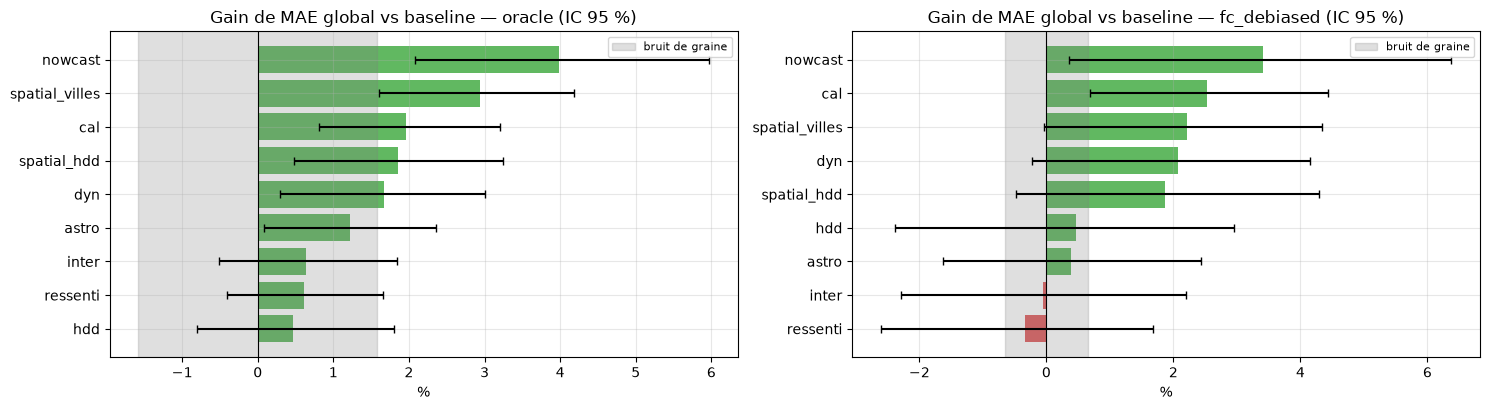

In [113]:
fig, axes = plt.subplots(1, len(MODES), figsize=(7.5 * len(MODES), 4.2), squeeze=False)
for ax, mode in zip(axes[0], MODES):
    t = SCREEN[mode].sort_values("gain_global")
    xerr = np.vstack([t["gain_global"] - t["lo_global"], t["hi_global"] - t["gain_global"]])
    ax.barh(t.index.str.replace("add_", ""), t["gain_global"], xerr=xerr, color=np.where(t["gain_global"] >= 0, "tab:green", "tab:red"), alpha=0.75, capsize=3)
    ax.axvline(0, color="k", lw=0.8)
    nz = NOISE.get((mode, "global"), 0)
    ax.axvspan(-nz, nz, color="grey", alpha=0.25, label="bruit de graine")
    ax.set_title(f"Gain de MAE global vs baseline — {mode} (IC 95 %)"); ax.set_xlabel("%"); ax.legend(fontsize=8)
plt.tight_layout(); save_fig("05_criblage_gain_global"); plt.show()

In [114]:
# Sélection : un bloc est retenu s'il aide globalement (✅/🟡) ou franchement par grand froid (✅), et ne dégrade pas le mode prévu
SELECTED = []
for b in BLOCKS:
    n = f"add_{b}"
    vo, vf = SCREEN["oracle"].loc[n, "verdict_global"], SCREEN["oracle"].loc[n, "verdict_froid"]
    vp = SCREEN["fc_debiased"].loc[n, "verdict_global"] if "fc_debiased" in SCREEN else "⚪"
    if (vo in ("✅", "🟡") or vf == "✅") and vp != "❌":
        SELECTED.append(b)
print("Blocs retenus pour l'ensemble complet :", SELECTED or "aucun")
print("Écartés :", [b for b in BLOCKS if b not in SELECTED])

Blocs retenus pour l'ensemble complet : ['dyn', 'astro', 'cal', 'nowcast', 'spatial_hdd', 'spatial_villes']
Écartés : ['hdd', 'ressenti', 'inter']


## 9. Ensemble complet et ablation inversée

Le criblage additif peut manquer les variables **redondantes** (deux blocs qui apportent la même information se masquent l'un l'autre) ou les **complémentaires**. On teste donc :

- `full` : baseline + tous les blocs retenus ;
- `full − bloc` pour chaque bloc retenu : si l'ensemble complet fait *mieux* que `full − bloc`, le bloc apporte quelque chose *en plus des autres*.

In [115]:
FULL_COLS = [c for b in SELECTED for c in BLOCK_COLS[b]]
LOO_TAB = None
if SELECTED:
    run_variant("full", FULL_COLS)
    FULL_TAB = {m: compare(["full"], mode=m) for m in MODES}
    print("Ensemble complet vs baseline :")
    for m in MODES:
        display(pretty(FULL_TAB[m]).rename(index={"full": f"full ({m})"}))
    if P["loo"] and len(SELECTED) >= 2:
        print("\nAblation inversée : apport de chaque bloc à l'ensemble complet")
        rows = []
        for b in SELECTED:
            run_variant(f"loo_{b}", [c for bb in SELECTED if bb != b for c in BLOCK_COLS[bb]])
            for m in MODES:
                r = compare(["full"], ref=f"loo_{b}", mode=m, K=len(SELECTED))
                rows.append({"bloc": b, "mode": m, **r.iloc[0].to_dict()})
        LOO_TAB = pd.DataFrame(rows)
        for m in MODES:
            t = LOO_TAB[LOO_TAB["mode"] == m].set_index("bloc")
            print(f"\nMode {m} : gain de `full` par rapport à `full` privé du bloc (= apport du bloc)")
            display(pretty(t))
else:
    print("Aucun bloc retenu : on garde la baseline.")

  full                         cache
Ensemble complet vs baseline :


,MAE,global (2070 j),froid (103 j),grand_froid (12 j)
variante,,,,
full (oracle),866.000,+7.60 % [+5.33 ; +9.72] ✅,+8.94 % [+0.48 ; +16.10] ✅,+15.73 % [+8.87 ; +23.89] ✅


,MAE,global (731 j),froid (35 j),grand_froid (4 j)
variante,,,,
full (fc_debiased),853.000,+8.62 % [+5.25 ; +12.10] ✅,+10.98 % [-5.13 ; +23.84] ⚪,+20.11 % [+nan ; +nan] n/a



Ablation inversée : apport de chaque bloc à l'ensemble complet
  loo_dyn                      cache
  loo_astro                    cache
  loo_cal                      cache
  loo_nowcast                  cache
  loo_spatial_hdd              cache
  loo_spatial_villes           cache

Mode oracle : gain de `full` par rapport à `full` privé du bloc (= apport du bloc)


,MAE,global (2070 j),froid (103 j),grand_froid (12 j)
bloc,,,,
dyn,866.000,+1.66 % [+0.32 ; +2.88] 🟡,+4.24 % [-0.76 ; +9.03] ⚪,+15.20 % [+8.00 ; +23.31] ✅
astro,866.000,+0.40 % [-0.84 ; +1.58] ⚪,-0.85 % [-5.61 ; +4.00] ⚪,+7.62 % [-2.67 ; +16.35] ⚪
cal,866.000,+0.60 % [-0.81 ; +1.97] ⚪,-0.55 % [-7.01 ; +5.64] ⚪,+1.48 % [-7.49 ; +12.15] ⚪
nowcast,866.000,+3.29 % [+1.47 ; +4.98] ✅,+1.34 % [-4.98 ; +6.35] ⚪,+5.58 % [-1.60 ; +11.26] ⚪
spatial_hdd,866.000,-0.41 % [-1.63 ; +0.75] ⚪,+3.09 % [-1.33 ; +7.15] ⚪,+13.57 % [+4.82 ; +24.17] ✅
spatial_villes,866.000,+0.31 % [-0.96 ; +1.59] ⚪,-1.08 % [-6.68 ; +4.32] ⚪,-0.08 % [-7.50 ; +9.60] ⚪



Mode fc_debiased : gain de `full` par rapport à `full` privé du bloc (= apport du bloc)


,MAE,global (731 j),froid (35 j),grand_froid (4 j)
bloc,,,,
dyn,853.000,+2.24 % [+0.05 ; +4.47] 🟡,+0.37 % [-5.67 ; +7.24] ⚪,+19.53 % [+nan ; +nan] n/a
astro,853.000,+0.32 % [-1.98 ; +2.61] ⚪,-3.54 % [-10.59 ; +4.70] ⚪,+11.56 % [+nan ; +nan] n/a
cal,853.000,+2.49 % [+0.43 ; +4.63] 🟡,-5.93 % [-10.32 ; -0.07] ❌,+7.17 % [+nan ; +nan] n/a
nowcast,853.000,+4.66 % [+1.76 ; +7.41] ✅,+6.93 % [+0.68 ; +13.90] 🟡,+16.64 % [+nan ; +nan] n/a
spatial_hdd,853.000,+1.07 % [-0.86 ; +3.10] ⚪,-1.37 % [-5.66 ; +2.00] ⚪,+16.72 % [+nan ; +nan] n/a
spatial_villes,853.000,+1.64 % [-0.26 ; +3.52] ⚪,-2.36 % [-10.14 ; +4.08] ⚪,+1.08 % [+nan ; +nan] n/a


### Ensemble recommandé

Un bloc est **conservé** s'il apporte quelque chose *en plus des autres* : son ablation inversée est ✅ ou 🟡 en mode oracle (sans ablation possible, tous les blocs retenus sont conservés). C'est cet ensemble, `KEEP`, qui est recommandé, et c'est lui que la confirmation de la section 13 doit valider.

In [116]:
def _apport(b):
    r = LOO_TAB[(LOO_TAB["bloc"] == b) & (LOO_TAB["mode"] == "oracle")]
    return r["verdict_global"].iloc[0]


KEEP = [b for b in SELECTED if LOO_TAB is None or _apport(b) in ("✅", "🟡")]
KEEP_COLS = [c for b in KEEP for c in BLOCK_COLS[b]]
print("Blocs retenus au criblage :", SELECTED or "aucun")
print("Blocs conservés après ablation inversée (ensemble recommandé) :", KEEP or "aucun")

Blocs retenus au criblage : ['dyn', 'astro', 'cal', 'nowcast', 'spatial_hdd', 'spatial_villes']
Blocs conservés après ablation inversée (ensemble recommandé) : ['dyn', 'nowcast']


## 10. Tests de modèle (autres que des variables)

Sur l'ensemble de variables retenu, on teste des changements de **modèle**. Chacun est comparé à `full` (mêmes variables, réglages de production) :

| Variante | Idée |
|---|---|
| `obj_l1` | l'objectif d'entraînement (L2 par défaut) n'est pas la métrique (MAE) : optimiser directement la valeur absolue. Attention : le gradient L1 converge plus lentement, et le nombre d'arbres est fixe : un résultat négatif peut venir d'un manque d'arbres |
| `obj_huber` | compromis robuste aux pointes exceptionnelles |
| `linear_tree` | feuilles linéaires : un arbre classique est constant par morceaux et **ne peut pas extrapoler** au-delà du froid déjà vu |
| `mono_hdd` | contrainte de monotonie croissante sur les degrés-jours du jour cible (plus froid ⇒ plus de consommation, à variables égales) : régularise la queue froide où les données sont rares. Exploratoire : à valider par le test d'extrapolation |
| `ff05` | `feature_fraction = 0,5` : avec plus de variables corrélées, moins de variables par arbre |
| `leaves31` | arbres plus petits (31 feuilles, 200 observations minimum par feuille) |
| `hl3` | pondération par récence (demi-vie 3 ans), pour suivre la dérive du niveau |
| `seed_avg3` | moyenne de 3 graines : plafond du gain apporté par la seule réduction de variance |

In [117]:
MODEL_SPECS = {
    "obj_l1":      dict(params={"objective": "l1"}),
    "obj_huber":   dict(params={"objective": "huber", "alpha": 800.0}),
    "linear_tree": dict(params={"linear_tree": True, "linear_lambda": 1.0}),
    "mono_hdd":    dict(mono="hdd"),
    "ff05":        dict(params={"feature_fraction": 0.5}),
    "leaves31":    dict(params={"num_leaves": 31, "min_data_in_leaf": 200}),
    "hl3":         dict(half_life=3.0),
    "seed_avg3":   dict(seeds=(0, 1, 2)),
}
HDD_MONO = lambda cols: [c for c in cols if re.fullmatch(r"hdd\d+_j|hdd17_pop(_j)?", c)]

MODEL_TAB, MODEL_RAN = None, []
BASE_FEATS = FULL_COLS if SELECTED else []
BASE_NAME = "full" if SELECTED else "baseline"
if not SELECTED:
    print("Pas d'ensemble retenu : les tests de modèle portent sur la baseline.")
if P["models"]:
    for mname in P["models"]:
        spec = dict(MODEL_SPECS[mname])
        if spec.pop("mono", None):
            mono_cols = HDD_MONO(FEATURE_COLUMNS + BASE_FEATS)
            if not mono_cols:
                print(f"  {mname:28s} ignoré (aucune variable de degrés-jours du jour cible dans le jeu)")
                continue
            spec["mono_cols"] = mono_cols
        try:
            run_variant(f"m_{mname}", BASE_FEATS, **spec)
            MODEL_RAN.append(mname)
        except Exception as e:                                             # ex. linear_tree incompatible avec un réglage
            print(f"  {mname:28s} ÉCHEC : {type(e).__name__}: {str(e)[:120]}")
    if MODEL_RAN:
        rows = []
        for m in MODES:
            t = compare([f"m_{x}" for x in MODEL_RAN], ref=BASE_NAME, mode=m)
            rows.append(t.assign(mode=m))
            print(f"\n=== Mode {m} : gain vs `{BASE_NAME}` (mêmes variables, réglages de production) ===")
            display(pretty(t))
        MODEL_TAB = pd.concat(rows)

  m_obj_l1                     cache
  m_obj_huber                  cache
  m_linear_tree                cache
  m_mono_hdd                   cache
  m_ff05                       cache
  m_leaves31                   cache
  m_hl3                        cache
  m_seed_avg3                  cache

=== Mode oracle : gain vs `full` (mêmes variables, réglages de production) ===


,MAE,global (2070 j),froid (103 j),grand_froid (12 j)
variante,,,,
m_obj_l1,877.000,-1.17 % [-2.81 ; +0.40] ⚪,+0.87 % [-6.45 ; +7.67] ⚪,-4.46 % [-22.05 ; +7.55] ⚪
m_obj_huber,901.000,-3.93 % [-5.73 ; -2.09] ❌,-8.68 % [-15.43 ; -0.84] ❌,-22.15 % [-33.21 ; -7.48] ❌
m_linear_tree,833.000,+3.85 % [-1.06 ; +7.15] ⚪,-21.29 % [-73.29 ; +11.16] ⚪,+6.71 % [-18.84 ; +25.63] ⚪
m_mono_hdd,860.000,+0.70 % [-0.12 ; +1.58] ⚪,+0.86 % [-2.97 ; +4.48] ⚪,+1.67 % [-4.73 ; +6.63] ⚪
m_ff05,856.000,+1.15 % [-0.15 ; +2.56] ⚪,-2.92 % [-8.84 ; +2.86] ⚪,-10.97 % [-28.45 ; +1.66] ⚪
m_leaves31,876.000,-1.09 % [-2.22 ; +0.04] ⚪,+0.01 % [-6.44 ; +5.94] ⚪,-4.43 % [-20.95 ; +5.82] ⚪
m_hl3,863.000,+0.44 % [-0.85 ; +1.78] ⚪,+0.90 % [-4.61 ; +6.18] ⚪,+1.51 % [-10.01 ; +12.62] ⚪
m_seed_avg3,823.000,+5.05 % [+4.40 ; +5.78] ✅,+1.75 % [-1.05 ; +4.84] ⚪,-5.00 % [-8.16 ; -2.42] ❌



=== Mode fc_debiased : gain vs `full` (mêmes variables, réglages de production) ===


,MAE,global (731 j),froid (35 j),grand_froid (4 j)
variante,,,,
m_obj_l1,869.000,-1.85 % [-4.61 ; +0.99] ⚪,+9.55 % [+3.43 ; +14.34] ✅,-0.25 % [+nan ; +nan] n/a
m_obj_huber,880.000,-3.15 % [-6.13 ; -0.21] ❌,+0.19 % [-6.12 ; +8.54] ⚪,-32.97 % [+nan ; +nan] n/a
m_linear_tree,797.000,+6.51 % [+3.63 ; +9.52] ✅,+15.60 % [+0.54 ; +28.20] 🟡,+35.33 % [+nan ; +nan] n/a
m_mono_hdd,848.000,+0.63 % [-0.95 ; +2.21] ⚪,+3.36 % [-2.12 ; +8.98] ⚪,+7.75 % [+nan ; +nan] n/a
m_ff05,828.000,+2.88 % [+0.71 ; +5.05] 🟡,+0.14 % [-6.95 ; +7.88] ⚪,-20.26 % [+nan ; +nan] n/a
m_leaves31,866.000,-1.52 % [-3.86 ; +0.93] ⚪,+4.74 % [-3.09 ; +12.31] ⚪,+2.43 % [+nan ; +nan] n/a
m_hl3,841.000,+1.44 % [-1.04 ; +3.76] ⚪,+2.39 % [-5.19 ; +8.11] ⚪,-11.29 % [+nan ; +nan] n/a
m_seed_avg3,823.000,+3.55 % [+2.31 ; +4.69] ✅,-0.98 % [-3.16 ; +0.70] ⚪,-5.96 % [+nan ; +nan] n/a


## 11. Grand froid

### 11.a Les jours froids de la période de sélection

Les tableaux précédents donnent déjà les périmètres `froid` (≤ 3 °C) et `grand_froid` (≤ 0 °C). Ici, le détail des **épisodes** (jours consécutifs), car cinq jours froids d'une même vague comptent pour un seul événement indépendant.

In [118]:
sel_days = T_DAY_OBS.loc[(T_DAY_OBS.index >= EVAL_START.tz_localize(None)) & (T_DAY_OBS.index < HOLDOUT_START.tz_localize(None))]
covid = pd.Series(False, index=sel_days.index)
for a, b in EVAL_EXCLUDE:
    covid |= (sel_days.index >= a.tz_localize(None)) & (sel_days.index < b.tz_localize(None))
sel_days = sel_days[~covid]
rows = []
for thr in (5, 3, 0, -3):
    cold = (sel_days <= thr)
    ep = (cold & ~cold.shift(1, fill_value=False)).sum()
    rows.append({"seuil (°C, moyenne journalière)": f"≤ {thr}", "jours": int(cold.sum()), "épisodes": int(ep),
                 "dont ≥ 3 jours consécutifs": int(((cold.groupby((~cold).cumsum()).transform("sum") >= 3) & cold & ~cold.shift(1, fill_value=False)).sum())})
display(pd.DataFrame(rows).set_index("seuil (°C, moyenne journalière)"))
print(f"Période de sélection : {sel_days.index.min().date()} → {sel_days.index.max().date()} (COVID exclu) — min {sel_days.min():.1f} °C le {sel_days.idxmin().date()}")
print("Sous 0 °C, si le nombre d'épisodes est petit (< 10), aucune conclusion « grand froid » ne peut être solide, quel que soit le gain observé.")

,jours,épisodes,dont ≥ 3 jours consécutifs
"seuil (°C, moyenne journalière)",,,
≤ 5,219,51,29
≤ 3,103,30,14
≤ 0,12,6,1
≤ -3,1,1,0


Période de sélection : 2018-01-01 → 2024-12-31 (COVID exclu) — min -3.4 °C le 2018-02-27
Sous 0 °C, si le nombre d'épisodes est petit (< 10), aucune conclusion « grand froid » ne peut être solide, quel que soit le gain observé.


### 11.b Test d'extrapolation au froid

Un arbre de décision est constant par morceaux : **il ne peut pas prédire au-delà de ce qu'il a vu**. Le vrai test d'une variable « grand froid » est donc de savoir si elle aide le modèle à extrapoler.

**Protocole :** mêmes réentraînements que d'habitude, mais on **retire de l'entraînement tous les jours dont la température moyenne est sous le seuil** (10ᵉ centile des jours de décembre à février de tout l'historique) ; on évalue ensuite **uniquement sur ces jours froids** de la période de sélection (le modèle ne les a jamais vus). On compare les variantes dans ces conditions, et on mesure la perte due à l'extrapolation par rapport à l'entraînement normal.

In [119]:
EXTRAP_TAB, EXTRAP_NUM = None, None
if P["extrap"]:
    win = T_DAY_OBS.loc[(T_DAY_OBS.index.month.isin([12, 1, 2])) & (T_DAY_OBS.index < HOLDOUT_START.tz_localize(None))]
    THR = float(win.quantile(0.10))
    cold_rows = (T_DAY_OBS.reindex(LOCAL_DAY.to_numpy()).to_numpy() <= THR)
    SCOPE_MASK["extrap"] = T_DAY_OBS <= THR
    print(f"Seuil d'extrapolation : {THR:.1f} °C ({int(cold_rows.sum() / 48)} jours retirés de l'entraînement)")

    specs = {"x_baseline": ([], {})}
    for b in SELECTED:
        specs[f"x_{b}"] = (BLOCK_COLS[b], {})
    if len(SELECTED) > 1:
        specs["x_full"] = (FULL_COLS, {})
    if SELECTED:
        if "linear_tree" in MODEL_RAN:
            specs["x_full_linear_tree"] = (FULL_COLS, MODEL_SPECS["linear_tree"])
        if "mono_hdd" in MODEL_RAN:
            specs["x_full_mono_hdd"] = (FULL_COLS, dict(mono_cols=HDD_MONO(FEATURE_COLUMNS + FULL_COLS)))
    for n, (cols, kw) in specs.items():
        try:
            run_variant(n, cols, exclude_train=cold_rows, modes=["oracle"], **kw)
        except Exception as e:
            print(f"  {n:28s} ÉCHEC : {type(e).__name__}: {str(e)[:120]}")
    ok = [n for n in specs if n in PRED]
    if len(ok) > 1:
        normal_of = {"x_baseline": "baseline", "x_full": "full", "x_full_linear_tree": "m_linear_tree", "x_full_mono_hdd": "m_mono_hdd"}
        rows = []
        for n in ok:
            normal = normal_of.get(n, n.replace("x_", "add_", 1))
            fr = eval_frame(["baseline", n], "oracle")
            in_cold = SCOPE_MASK["extrap"].reindex(LOCAL_DAY.reindex(fr.index).to_numpy()).fillna(False).to_numpy(dtype=bool)
            e_x = (PRED[n]["oracle"].reindex(fr.index)[in_cold] - fr["y"][in_cold]).abs().mean()
            e_n = (PRED[normal]["oracle"].reindex(fr.index)[in_cold] - fr["y"][in_cold]).abs().mean() if normal in PRED else np.nan
            rows.append({"variante": n, "MAE jours froids (extrapolation)": e_x, "MAE jours froids (entraînement normal)": e_n})
        ext = pd.DataFrame(rows).set_index("variante")
        ext["perte due à l'extrapolation %"] = (ext.iloc[:, 0] / ext.iloc[:, 1] - 1) * 100
        tab = compare([n for n in ok if n != "x_baseline"], ref="x_baseline", mode="oracle", scopes=("extrap",))
        EXTRAP_NUM = tab
        EXTRAP_TAB = ext.join(pretty(tab, scopes=("extrap",)).drop(columns="MAE"))
        display(EXTRAP_TAB.round(1))
        print("`gain` = par rapport à x_baseline, sur les seuls jours froids jamais vus à l'entraînement. Une perte due à l'extrapolation")
        print("plus faible que celle de x_baseline indique une variante qui extrapole mieux.")
else:
    print("Test d'extrapolation désactivé dans ce profil.")

Seuil d'extrapolation : 1.7 °C (127 jours retirés de l'entraînement)
  x_baseline                   cache
  x_dyn                        cache
  x_astro                      cache
  x_cal                        cache
  x_nowcast                    cache
  x_spatial_hdd                cache
  x_spatial_villes             cache
  x_full                       cache
  x_full_linear_tree           cache
  x_full_mono_hdd              cache


,MAE jours froids (extrapolation),MAE jours froids (entraînement normal),perte due à l'extrapolation %,extrap (45 j)
variante,,,,
x_baseline,1993.700,1570.400,27.000,NaN
x_dyn,1964.900,1482.600,32.500,+1.44 % [-7.41 ; +11.61] ⚪
x_astro,1988.000,1544.800,28.700,+0.29 % [-4.40 ; +4.63] ⚪
x_cal,2189.200,1486.100,47.300,-9.81 % [-14.12 ; -5.07] ❌
x_nowcast,1817.100,1500.500,21.100,+8.86 % [+2.61 ; +17.44] ✅
x_spatial_hdd,1971.500,1508.800,30.700,+1.11 % [-6.23 ; +9.23] ⚪
x_spatial_villes,1809.600,1451.300,24.700,+9.23 % [+0.75 ; +19.42] 🟡
x_full,1643.900,1420.400,15.700,+17.54 % [+8.00 ; +26.60] ✅
x_full_linear_tree,1437.200,1310.200,9.700,+27.91 % [+21.12 ; +34.58] ✅


`gain` = par rapport à x_baseline, sur les seuls jours froids jamais vus à l'entraînement. Une perte due à l'extrapolation
plus faible que celle de x_baseline indique une variante qui extrapole mieux.


## 12. Stabilité : le gain est-il régulier ?

Un gain moyen peut venir d'une seule année, d'une seule saison ou d'un type de jour. On décompose le gain de la meilleure configuration (`full`, sinon le meilleur bloc) par **année**, **saison**, **type de jour**, **tranche horaire** et **tranche de température**. Un gain robuste est positif sur (presque) toutes les lignes.

In [120]:
CAND = "full" if SELECTED else (SCREEN["oracle"]["gain_global"].idxmax() if len(SCREEN["oracle"]) else "baseline")
STAB = {}
for m in MODES:
    for by in ("année", "saison", "type_jour", "heure", "tranche_T"):
        g, _ = slice_gain(CAND, "baseline", m, by)
        STAB[(m, by)] = g

def show_heat(tab, title):
    try:
        display(tab.style.format("{:+.1f}").background_gradient(cmap="RdYlGn", axis=None, vmin=-6, vmax=6).set_caption(title))
    except Exception:
        display(tab.round(1))

for by in ("année", "saison", "type_jour", "heure", "tranche_T"):
    t = pd.DataFrame({m: STAB[(m, by)] for m in MODES}).T
    show_heat(t, f"Gain de MAE (%) de `{CAND}` vs baseline, par {by}")
pos = STAB[("oracle", "année")]
print(f"Mode oracle : gain positif sur {int((pos > 0).sum())} années sur {len(pos)}.")
if "fc_debiased" in MODES:
    pf = STAB[("fc_debiased", "année")]
    print(f"Mode prévu  : gain positif sur {int((pf > 0).sum())} années sur {len(pf)}.")

date_heure,2018,2019,2020,2021,2022,2023,2024
oracle,+1.9,+12.2,+4.0,-1.4,+7.8,+12.1,+8.7
fc_debiased,+nan,+nan,+nan,+nan,+nan,+9.6,+7.6


,hiver,mi-saison,été
oracle,+8.6,+8.8,+3.1
fc_debiased,+9.4,+6.4,+8.9


,dimanche,férié,pont,samedi,semaine
oracle,+7.9,+2.7,-4.7,+8.0,+7.9
fc_debiased,+7.0,-0.1,+16.7,+12.1,+8.7


,0-5 h,6-9 h,10-13 h,14-17 h,18-20 h,21-23 h
oracle,+10.3,+6.4,+8.1,+6.5,+7.4,+6.3
fc_debiased,+11.0,+9.6,+8.2,+6.8,+7.2,+8.3


,<0,0-5,5-10,10-15,15-20,20-25,>25
oracle,+10.3,+9.8,+10.0,+6.8,+4.4,+3.4,+4.2
fc_debiased,+9.9,+14.3,+11.6,+2.8,+5.6,+7.5,+16.5


Mode oracle : gain positif sur 6 années sur 7.
Mode prévu  : gain positif sur 2 années sur 2.


## 13. Confirmation aveugle : protocole de production sur 2025 → aujourd'hui

Ces données n'ont **jamais servi** à choisir des variables ni des réglages. On refait la comparaison avec le protocole exact du notebook 04 : **réentraînement mensuel**, hyperparamètres de production, biais de température réestimé chaque mois. Si le gain observé sur 2018-2024 est réel, il doit se retrouver ici.

On compare à RTE J-1 : la baseline, `conf_full` (tous les blocs retenus au criblage), `conf_keep` (l'ensemble **recommandé**, après ablation inversée, s'il diffère) et, le cas échéant, jusqu'à deux réglages de modèle jugés prometteurs (✅/🟡 dans un mode, jamais ❌) appliqués à l'ensemble de référence. **C'est `conf_keep` qui valide (ou non) la recommandation.**

In [121]:
CONF_ROUNDS = P["confirm_rounds"] or DEFAULT_ROUNDS
CONFIRM_MODEL_VARIANTS = 2        # nombre max de variantes de modèle confirmées (0 = aucune) ; chacune coûte un réentraînement mensuel complet
conf_specs = {"conf_baseline": ([], {})}
REF_CONF, REF_COLS = None, []
if SELECTED:
    conf_specs["conf_full"] = (FULL_COLS, {})                               # tous les blocs retenus au criblage
    REF_CONF, REF_COLS = "conf_full", FULL_COLS
if KEEP and set(KEEP) != set(SELECTED):
    conf_specs["conf_keep"] = (KEEP_COLS, {})                               # ensemble RECOMMANDÉ (après ablation inversée)
    REF_CONF, REF_COLS = "conf_keep", KEEP_COLS
if REF_CONF and MODEL_TAB is not None and CONFIRM_MODEL_VARIANTS:
    # une variante de modèle est confirmée si elle est ✅/🟡 dans au moins un mode et jamais ❌ (périmètre global)
    cand = []
    for mname in MODEL_RAN:
        t = MODEL_TAB.loc[f"m_{mname}"]
        vs_ = list(t["verdict_global"]) if isinstance(t, pd.DataFrame) else [t["verdict_global"]]
        gs_ = list(t["gain_global"]) if isinstance(t, pd.DataFrame) else [t["gain_global"]]
        if any(v in ("✅", "🟡") for v in vs_) and "❌" not in vs_:
            cand.append((float(np.mean(gs_)), mname))
    for _, mname in sorted(cand, reverse=True)[:CONFIRM_MODEL_VARIANTS]:
        spec = dict(MODEL_SPECS[mname])
        if spec.pop("mono", None):
            spec["mono_cols"] = HDD_MONO(FEATURE_COLUMNS + REF_COLS)
        conf_specs[f"{REF_CONF}_{mname}"] = (REF_COLS, spec)
print(f"Confirmation : {list(conf_specs)} | réentraînement mensuel, {CONF_ROUNDS} arbres | {HOLDOUT_START.date()} → {TEST_END.date()}")
for n, (cols, kw) in conf_specs.items():
    run_variant(n, cols, rounds=CONF_ROUNDS, start=HOLDOUT_START, end=TEST_END, retrain=1, **kw)

CONF = {}
for m in MODES:
    names_c = list(conf_specs) + (["rte_j1"] if "rte_j1" in PRED else [])
    mt = metrics_table(names_c, m, HOLDOUT_START, TEST_END)
    cmp_ = compare([n for n in conf_specs if n != "conf_baseline"], ref="conf_baseline", mode=m, start=HOLDOUT_START, end=TEST_END) if len(conf_specs) > 1 else None
    CONF[m] = (mt, cmp_)
    print(f"\n=== Mode {m} — {int(mt['n'].iloc[0]):,} points communs, 2025 → fin des données consolidées ===")
    display(mt.round({"MAE": 0, "RMSE": 0, "biais": 0, "MAPE %": 2, "err_pointe": 0, "n": 0}))
    if cmp_ is not None:
        display(pretty(cmp_))

Confirmation : ['conf_baseline', 'conf_full', 'conf_keep', 'conf_keep_linear_tree', 'conf_keep_seed_avg3'] | réentraînement mensuel, 1000 arbres | 2025-01-01 → 2026-07-01
  conf_baseline                cache
  conf_full                    cache
  conf_keep                     18 entraînements,  1477 s (82.1 s / entraînement, 55 variables)
  conf_keep_linear_tree         18 entraînements,  1752 s (97.3 s / entraînement, 55 variables)
  conf_keep_seed_avg3           54 entraînements,  3633 s (67.3 s / entraînement, 55 variables)

=== Mode oracle — 26,204 points communs, 2025 → fin des données consolidées ===


,MAE,RMSE,biais,MAPE %,err_pointe,n
conf_baseline,914.000,1235.000,-123.000,1.750,958.000,26204.000
conf_full,804.000,1113.000,-139.000,1.550,826.000,26204.000
conf_keep,822.000,1127.000,-162.000,1.580,878.000,26204.000
conf_keep_linear_tree,809.000,1126.000,-153.000,1.560,869.000,26204.000
conf_keep_seed_avg3,787.000,1085.000,-160.000,1.520,844.000,26204.000
rte_j1,1379.000,1718.000,-1055.000,2.740,1418.000,26204.000


,MAE,global (546 j),froid (32 j),grand_froid (4 j)
variante,,,,
conf_full,804.000,+12.10 % [+6.70 ; +16.94] ✅,+6.68 % [-20.31 ; +29.15] ⚪,+29.17 % [+nan ; +nan] n/a
conf_keep,822.000,+10.08 % [+6.00 ; +13.99] ✅,+5.81 % [-4.35 ; +14.19] ⚪,+18.98 % [+nan ; +nan] n/a
conf_keep_linear_tree,809.000,+11.56 % [+6.78 ; +16.21] ✅,+9.61 % [-0.95 ; +18.15] ⚪,+2.38 % [+nan ; +nan] n/a
conf_keep_seed_avg3,787.000,+13.96 % [+10.08 ; +17.77] ✅,+7.63 % [-8.66 ; +21.41] ⚪,+25.67 % [+nan ; +nan] n/a



=== Mode fc_debiased — 26,204 points communs, 2025 → fin des données consolidées ===


,MAE,RMSE,biais,MAPE %,err_pointe,n
conf_baseline,921.000,1244.000,-131.000,1.760,964.000,26204.000
conf_full,813.000,1118.000,-128.000,1.560,846.000,26204.000
conf_keep,835.000,1138.000,-164.000,1.610,901.000,26204.000
conf_keep_linear_tree,822.000,1120.000,-157.000,1.580,876.000,26204.000
conf_keep_seed_avg3,802.000,1099.000,-159.000,1.540,868.000,26204.000
rte_j1,1379.000,1718.000,-1055.000,2.740,1418.000,26204.000


,MAE,global (546 j),froid (32 j),grand_froid (4 j)
variante,,,,
conf_full,813.000,+11.69 % [+6.60 ; +16.23] ✅,+3.96 % [-22.10 ; +26.44] ⚪,+37.69 % [+nan ; +nan] n/a
conf_keep,835.000,+9.29 % [+5.19 ; +13.30] ✅,+3.64 % [-6.80 ; +14.62] ⚪,+25.55 % [+nan ; +nan] n/a
conf_keep_linear_tree,822.000,+10.70 % [+6.11 ; +15.13] ✅,+5.70 % [-3.55 ; +12.85] ⚪,+20.22 % [+nan ; +nan] n/a
conf_keep_seed_avg3,802.000,+12.88 % [+8.99 ; +16.67] ✅,+5.34 % [-11.35 ; +21.19] ⚪,+34.17 % [+nan ; +nan] n/a


MAE (MW) par tranche de température nationale — mode fc_debiased, 2025 → fin :


,conf_baseline,conf_full,conf_keep,conf_keep_linear_tree,conf_keep_seed_avg3,rte_j1,n_demi-heures
temp_nat,,,,,,,
<0,1521.000,1211.000,1295.000,1222.000,1169.000,1505.000,381
0-5,1408.000,1194.000,1257.000,1251.000,1250.000,1477.000,2600
5-10,1094.000,945.000,946.000,939.000,908.000,1200.000,6332
10-15,889.000,786.000,796.000,760.000,761.000,1377.000,6837
15-20,656.000,597.000,620.000,621.000,591.000,1427.000,5188
20-25,651.000,616.000,640.000,616.000,604.000,1475.000,2930
>25,812.000,765.000,826.000,859.000,795.000,1535.000,1936


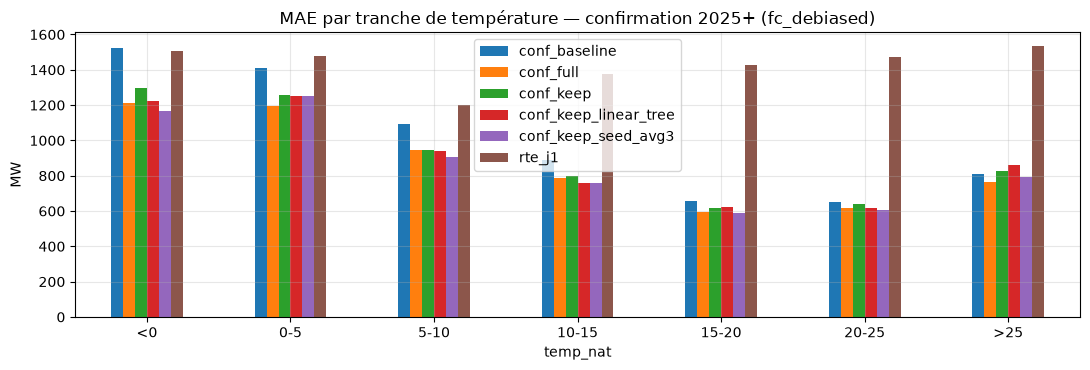

In [122]:
# Erreur par tranche de température sur la confirmation, en mode prévu si disponible
mode_c = MODES[-1]
BINS, LABELS = [-np.inf, 0, 5, 10, 15, 20, 25, np.inf], ["<0", "0-5", "5-10", "10-15", "15-20", "20-25", ">25"]
nm = list(conf_specs) + (["rte_j1"] if "rte_j1" in PRED else [])
fr = eval_frame(nm, mode_c, HOLDOUT_START, TEST_END)
band = pd.cut(df.loc[fr.index, "temp_nat"], BINS, labels=LABELS)
tr_tab = pd.DataFrame({n: (fr[n] - fr["y"]).abs().groupby(band, observed=True).mean() for n in nm})
tr_tab["n_demi-heures"] = band.value_counts().reindex(tr_tab.index)
print(f"MAE (MW) par tranche de température nationale — mode {mode_c}, 2025 → fin :")
display(tr_tab.round(0))
tr_tab.drop(columns="n_demi-heures").plot.bar(figsize=(11, 3.8), rot=0)
plt.title(f"MAE par tranche de température — confirmation 2025+ ({mode_c})"); plt.ylabel("MW")
plt.tight_layout(); save_fig("05_confirmation_par_temperature"); plt.show()

## 14. Sur quoi s'appuie le modèle ?

Deux mesures sur un modèle entraîné jusqu'au 30 décembre 2024 avec l'ensemble retenu :

- **importance en gain**, agrégée par bloc ;
- **importance par permutation de bloc** : on mélange *ensemble* les colonnes d'un bloc (en préservant leurs relations internes) sur 2025 → et on mesure la perte de MAE. Un bloc dont le mélange ne change rien n'est pas utilisé.

,part du gain %,perte de MAE si mélangé (MW)
base,84.400,5595.500
nowcast,9.600,489.500
dyn,2.400,349.100
astro,1.500,225.800
spatial_hdd,1.000,77.500
cal,0.600,91.600
spatial_villes,0.600,147.600


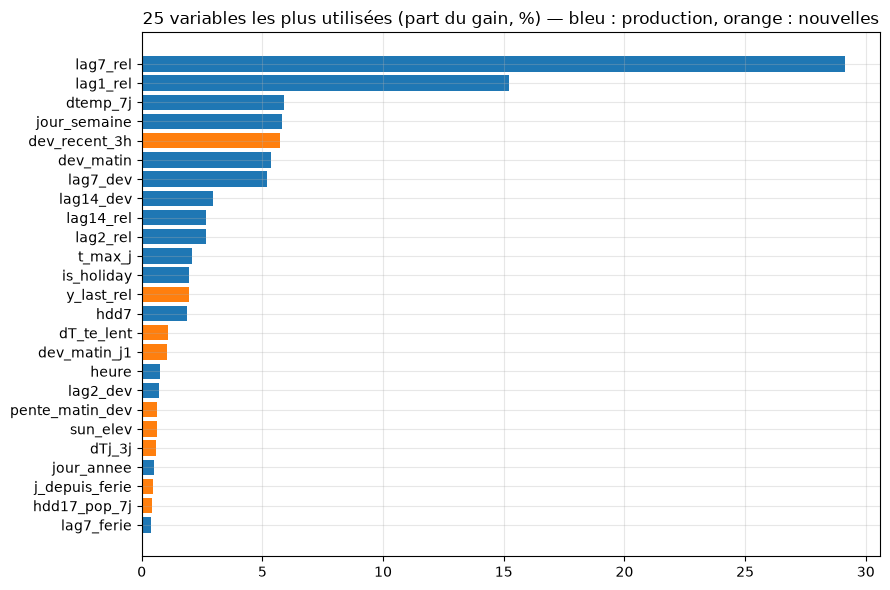

In [123]:
IMP = None
if SELECTED:
    feats = FEATURE_COLUMNS + FULL_COLS
    tr_end = HOLDOUT_START - pd.Timedelta(days=GAP_DAYS)
    model = fit_lgb(STORE.obs, y, mask_between(STORE.obs.index, TRAIN_START, tr_end), CONF_ROUNDS, None, None, tr_end, feats)
    g = pd.Series(model.feature_importance("gain"), index=feats)
    g_block = (g.groupby(g.index.map(STORE.col_block)).sum() / g.sum() * 100).sort_values()

    te = STORE.obs.loc[mask_between(STORE.obs.index, HOLDOUT_START, TEST_END)]
    te = te.loc[te["temp_nat"].notna() & y.reindex(te.index).notna()]
    mae0 = (predict_level(model, te, feats) - y.loc[te.index]).abs().mean()
    rng = np.random.default_rng(0)
    perm = {}
    for b in ["base", *SELECTED]:
        cols_b = FEATURE_COLUMNS if b == "base" else BLOCK_COLS[b]
        cols_b = [c for c in cols_b if c in feats and c not in ("level7",)]
        losses = []
        for _ in range(3):
            tp = te.copy()
            tp[cols_b] = te[cols_b].iloc[rng.permutation(len(te))].to_numpy()
            losses.append((predict_level(model, tp, feats) - y.loc[te.index]).abs().mean() - mae0)
        perm[b] = np.mean(losses)
    IMP = pd.DataFrame({"part du gain %": g_block, "perte de MAE si mélangé (MW)": pd.Series(perm)}).sort_values("part du gain %", ascending=False)
    display(IMP.round(1))
    top = g.sort_values(ascending=False).head(25)[::-1]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(top.index, top / g.sum() * 100, color=[{"base": "tab:blue"}.get(STORE.col_block[c], "tab:orange") for c in top.index])
    ax.set_title("25 variables les plus utilisées (part du gain, %) — bleu : production, orange : nouvelles"); plt.tight_layout(); save_fig("05_importance_variables"); plt.show()
else:
    print("Aucun bloc retenu.")

## 15. Décision et export

La recommandation est **mécanique** (règle écrite avant de regarder les résultats, pas ajustée après coup) :

1. un bloc est **retenu** s'il passe le criblage (section 8) ;
2. il est **conservé** dans la recommandation si, en plus, son apport à l'ensemble complet (ablation inversée, section 9) est ✅ ou 🟡 en mode oracle — sans cette étape, on ne peut pas exclure qu'il soit redondant ;
3. la recommandation n'est **confirmée** que si l'ensemble **recommandé** (`conf_keep`) améliore la MAE 2025+ dans le protocole de production (section 13) avec un IC à 95 % > 0 dans au moins un mode, sans dégradation dans l'autre. Un gain de bon signe mais dont l'IC inclut 0 est une *tendance*, pas une confirmation.

Rien de tout cela ne prouve un gain en production : cela dit ce que le protocole permet d'affirmer.

In [124]:
rows = []
for b in BLOCKS:
    n = f"add_{b}"
    r = {"bloc": b, "nb variables": len(BLOCK_COLS[b]), "retenu (criblage)": b in SELECTED}
    for m in MODES:
        tag = "oracle" if m == "oracle" else "prévu"
        r[f"gain {tag} %"] = SCREEN[m].loc[n, "gain_global"]
        r[f"verdict {tag}"] = SCREEN[m].loc[n, "verdict_global"]
    r["gain grand froid oracle %"] = SCREEN["oracle"].loc[n, "gain_grand_froid"]
    r["verdict grand froid"] = SCREEN["oracle"].loc[n, "verdict_grand_froid"]
    if LOO_TAB is not None and b in SELECTED:
        l = LOO_TAB[(LOO_TAB["bloc"] == b) & (LOO_TAB["mode"] == "oracle")].iloc[0]
        r["apport dans full %"], r["verdict apport"] = l["gain_global"], l["verdict_global"]
    if EXTRAP_NUM is not None and f"x_{b}" in EXTRAP_NUM.index:
        r["gain extrapolation froid %"] = EXTRAP_NUM.loc[f"x_{b}", "gain_extrap"]
    rows.append(r)
DECISION = pd.DataFrame(rows).set_index("bloc")

DECISION["recommandé"] = DECISION.index.isin(KEEP)
display(DECISION.round(2))

confirm_msgs = []
if REF_CONF in PRED:
    for m in MODES:
        c = CONF[m][1].loc[REF_CONF]
        confirm_msgs.append(f"mode {m} : {c['gain_global']:+.2f} % [{c['lo_global']:+.2f} ; {c['hi_global']:+.2f}] {c['verdict_global']}")
print("Blocs recommandés :", KEEP or "aucun (on garde les variables de production)")
if confirm_msgs:
    print(f"Confirmation 2025+ de l'ensemble recommandé `{REF_CONF}` (gain de MAE vs baseline) —", " | ".join(confirm_msgs))
    vs = [CONF[m][1].loc[REF_CONF, "verdict_global"] for m in MODES]
    gs = [CONF[m][1].loc[REF_CONF, "gain_global"] for m in MODES]
    if all(g > 0 for g in gs) and "❌" not in vs and any(v in ("✅", "🟡") for v in vs):
        print("→ CONFIRMÉ : gain positif dans tous les modes, IC à 95 % > 0 dans au moins un, aucune dégradation.")
    elif all(g > 0 for g in gs):
        print("→ TENDANCE POSITIVE NON SIGNIFICATIVE : le signe est bon mais l'IC inclut 0 sur 2025+. Ne pas conclure ; attendre plus de données ou un profil `complet`.")
    else:
        print("→ NON CONFIRMÉ : le gain de la sélection ne se retrouve pas sur 2025+ dans tous les modes. Ne pas intégrer sans investigation.")
OUT.mkdir(parents=True, exist_ok=True)
for m in MODES:
    SCREEN[m].to_csv(OUT / f"criblage_{m}.csv")
    CONF[m][0].to_csv(OUT / f"confirmation_metriques_{m}.csv")
    if CONF[m][1] is not None:
        CONF[m][1].to_csv(OUT / f"confirmation_gains_{m}.csv")
DECISION.to_csv(OUT / "decision.csv")
if LOO_TAB is not None:
    LOO_TAB.to_csv(OUT / "ablation_inversee.csv", index=False)
if MODEL_TAB is not None:
    MODEL_TAB.to_csv(OUT / "variantes_modele.csv")
if EXTRAP_TAB is not None:
    EXTRAP_TAB.to_csv(OUT / "extrapolation_froid.csv")
if IMP is not None:
    IMP.to_csv(OUT / "importance_blocs.csv")
(OUT / "recommandation.json").write_text(json.dumps({
    "profil": PROFILE, "periode_selection": [str(EVAL_START.date()), str(HOLDOUT_START.date())], "arbres": ROUNDS,
    "blocs_retenus": SELECTED, "blocs_recommandes": KEEP,
    "variables_recommandees": [c for b in KEEP for c in BLOCK_COLS[b]],
    "bruit_de_graine_pct": {f"{k[0]}|{k[1]}": v for k, v in NOISE.items()},
}, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"\nRésultats écrits dans {OUT}")

,nb variables,retenu (criblage),gain oracle %,verdict oracle,gain prévu %,verdict prévu,gain grand froid oracle %,verdict grand froid,apport dans full %,verdict apport,gain extrapolation froid %,recommandé
bloc,,,,,,,,,,,,
dyn,11,True,1.670,🟡,2.070,⚪,9.740,⚪,1.660,🟡,1.440,True
hdd,9,False,0.460,⚪,0.470,⚪,-3.830,⚪,NaN,NaN,NaN,False
ressenti,7,False,0.620,⚪,-0.340,⚪,4.500,🟡,NaN,NaN,NaN,False
astro,4,True,1.220,🟡,0.390,⚪,3.280,⚪,0.400,⚪,0.290,False
cal,5,True,1.970,🟡,2.520,🟡,4.820,🟡,0.600,⚪,-9.810,False
nowcast,5,True,3.990,✅,3.410,🟡,-2.560,⚪,3.290,✅,8.860,True
inter,4,False,0.640,⚪,-0.060,⚪,1.310,⚪,NaN,NaN,NaN,False
spatial_hdd,12,True,1.850,🟡,1.860,⚪,-1.310,⚪,-0.410,⚪,1.110,False
spatial_villes,10,True,2.940,🟡,2.210,⚪,4.410,⚪,0.310,⚪,9.230,False


Blocs recommandés : ['dyn', 'nowcast']
Confirmation 2025+ de l'ensemble recommandé `conf_keep` (gain de MAE vs baseline) — mode oracle : +10.08 % [+6.00 ; +13.99] ✅ | mode fc_debiased : +9.29 % [+5.19 ; +13.30] ✅
→ CONFIRMÉ : gain positif dans tous les modes, IC à 95 % > 0 dans au moins un, aucune dégradation.

Résultats écrits dans c:\Users\baptm\Downloads\conso-rte\reports\feature_experiments


## 16. Lecture, limites et suite

**Comment conclure.** Une famille de variables n'est digne d'entrer dans `src/conso/features.py` que si :

1. son gain est ✅ ou 🟡 en mode oracle **et** non ❌ en mode prévu (la météo réelle est prévue, pas observée) ;
2. il est positif sur la plupart des **années** et des **saisons** (section 12), pas seulement sur une vague de froid ;
3. son apport résiste à l'**ablation inversée** (elle n'est pas redondante avec les autres) ;
4. il est **confirmé** sur 2025+ dans le protocole de production (section 13) ;
5. elle passe les **audits** de la section 4.

**Limites à garder en tête.**

- **Peu d'événements de grand froid indépendants.** Sous 0 °C, quelques vagues seulement : un gain « grand froid » ne se démontre pas avec ces données seules. Le test d'extrapolation (11.b) est le meilleur substitut.
- **Météo prévue optimiste.** L'API de prévisions historiques n'est pas une vraie prévision J-1 émise à 10 h (notebook 03) : le coût de l'incertitude météo est sous-estimé, donc les variables très sensibles à la précision (villes individuelles, HDD par ville) pourraient perdre plus en exploitation.
- **Rolling origin moins fréquent que la production** (tous les 12 mois en profil `standard`, tous les mois en production) : niveaux de MAE légèrement plus élevés, mais comparaison entre variantes équitable. La section 13 revient au protocole exact.
- **Même nombre d'arbres pour toutes les variantes.** Un jeu beaucoup plus grand pourrait mériter plus d'arbres ; `ff05` et `leaves31` donnent une idée de la sensibilité.
- **Multiplicité.** Une vingtaine de variantes sont testées : quelques faux positifs sont attendus au seuil de 5 %. C'est pourquoi le verdict ✅ exige un IC corrigé et un gain supérieur à deux fois le bruit de graine.
- **Optimisme résiduel des variables de production** (`te`, `t_roll3` utilisent la température observée de D entière) : commun à toutes les variantes, voir l'audit 2/3.

**Pour intégrer un bloc.** (1) porter la fonction dans `src/conso/features.py` et étendre `FEATURE_COLUMNS` ; (2) ajouter les tests de `tests/test_features.py` (fuite de consommation, **fuite de météo**, fenêtre = historique complet) pour ces colonnes ; (3) pour les blocs **spatiaux**, l'API et le journal doivent récupérer la prévision **par ville** (aujourd'hui `weather.fetch_national_forecast` n'expose que l'agrégat national) et débiaiser chaque ville avec son propre biais horaire ; (4) relancer le notebook 04 et mettre à jour le README.